In [3]:
!kaggle datasets download -d anggundwilestari/walmart-sales-forecasting

Dataset URL: https://www.kaggle.com/datasets/anggundwilestari/walmart-sales-forecasting
License(s): other
walmart-sales-forecasting.zip: Skipping, found more recently modified local copy (use --force to force download)


In [4]:
import zipfile

with zipfile.ZipFile("walmart-sales-forecasting.zip", 'r') as zip_ref:
    zip_ref.extractall("walmart-sales-forecasting")

In [5]:
import os
os.listdir("walmart-sales-forecasting")

['test - Walmart Sales Forecast.csv',
 'Walmart Sales Forecast.ipynb',
 'train - Walmart Sales Forecast.csv',
 'stores - Walmart Sales Forecast.csv',
 'features - Walmart Sales Forecast.csv']

In [6]:
!pip install pmdarima

# Import Libraries

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
from statsmodels.tsa.statespace.sarimax import SARIMAX

from pmdarima import auto_arima

from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric,add_changepoints_to_plot

In [8]:
df = pd.read_csv("/content/walmart-sales-forecasting/train - Walmart Sales Forecast.csv")
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [9]:
print("Shape:", df.shape)
print("Date range:", df["Date"].min(), "→", df["Date"].max())
print("Unique weeks:", df["Date"].nunique())
print("Stores:", df["Store"].nunique(), "| Departments:", df["Dept"].nunique())

Shape: (421570, 5)
Date range: 2010-02-05 → 2012-10-26
Unique weeks: 143
Stores: 45 | Departments: 81


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB


# Overall Sales

## Missing values and Duplicates

In [11]:
print("Number of duplicates:", df.duplicated().sum())

Number of duplicates: 0


In [12]:
df.isna().sum()

,0
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday,0


In [13]:
df['Date'] = pd.to_datetime(df['Date'])

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
dtypes: bool(1), datetime64[ns](1), float64(1), int64(2)
memory usage: 13.3 MB


In [15]:
df.describe(include="all")

,Store,Dept,Date,Weekly_Sales,IsHoliday
count,421570.000000,421570.000000,421570,421570.000000,421570
unique,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,False
freq,NaN,NaN,NaN,NaN,391909
mean,22.200546,44.260317,2011-06-18 08:30:31.963375104,15981.258123,NaN
min,1.000000,1.000000,2010-02-05 00:00:00,-4988.940000,NaN
25%,11.000000,18.000000,2010-10-08 00:00:00,2079.650000,NaN
50%,22.000000,37.000000,2011-06-17 00:00:00,7612.030000,NaN
75%,33.000000,74.000000,2012-02-24 00:00:00,20205.852500,NaN
max,45.000000,99.000000,2012-10-26 00:00:00,693099.360000,NaN


- Mean (~ 15,981) vs median (~7,612) — the mean is much larger than the median. That usually means a long right tail: many smaller weekly sales values and a smaller number of very large ones.
- Std (~22,711) > mean — high spread relative to the average; weekly sales are volatile across rows.

## EDA

In [16]:
sns.set_theme(style="whitegrid")

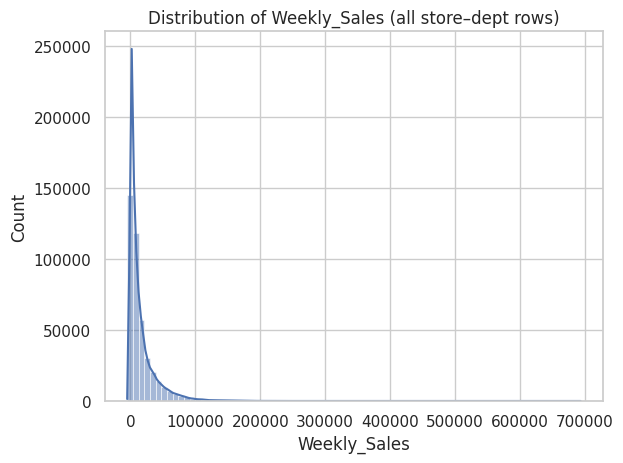

In [17]:
fig, ax = plt.subplots()
sns.histplot(df["Weekly_Sales"], bins=80, kde=True, ax=ax)
ax.set_title("Distribution of Weekly_Sales (all store–dept rows)")
ax.set_xlabel("Weekly_Sales")
plt.tight_layout()
plt.show()

- Tall stack near the left = most store–dept weeks have moderate or low sales.
- Thin tail out to large values = few rows with very high sales (same as max in describe)


In [18]:
holiday_sales = df.groupby("IsHoliday")["Weekly_Sales"].agg(["mean", "median", "count"])
holiday_sales

,mean,median,count
IsHoliday,,,
False,15901.445069,7589.95,391909
True,17035.823187,7947.74,29661


In [19]:
weekly_totals = (
    df.groupby("Date", as_index=False)
    .agg(Weekly_Sales_sum=("Weekly_Sales", "sum"), IsHoliday=("IsHoliday", "max"))
    .sort_values("Date")
    .reset_index(drop=True)
)

In [20]:
weekly_totals

,Date,Weekly_Sales_sum,IsHoliday
0,2010-02-05,49750740.50,False
1,2010-02-12,48336677.63,True
2,2010-02-19,48276993.78,False
3,2010-02-26,43968571.13,False
4,2010-03-05,46871470.30,False
...,...,...,...
138,2012-09-28,43734899.40,False
139,2012-10-05,47566639.31,False
140,2012-10-12,46128514.25,False
141,2012-10-19,45122410.57,False


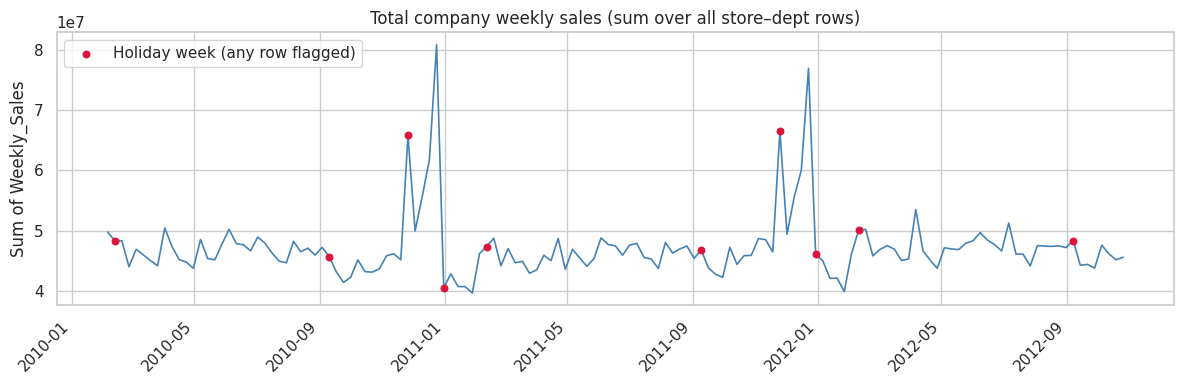

,Date,Weekly_Sales_sum,IsHoliday
0,2010-02-05,49750740.50,False
1,2010-02-12,48336677.63,True
2,2010-02-19,48276993.78,False
3,2010-02-26,43968571.13,False
4,2010-03-05,46871470.30,False


In [21]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(weekly_totals["Date"], weekly_totals["Weekly_Sales_sum"], color="steelblue", linewidth=1.2)
holiday_dates = weekly_totals.loc[weekly_totals["IsHoliday"], "Date"]
ax.scatter(
    holiday_dates,
    weekly_totals.set_index("Date").loc[holiday_dates, "Weekly_Sales_sum"],
    color="crimson",
    s=22,
    zorder=5,
    label="Holiday week (any row flagged)",
)
ax.set_title("Total company weekly sales (sum over all store–dept rows)")
ax.set_ylabel("Sum of Weekly_Sales")
plt.xticks(rotation=45, ha="right")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

weekly_totals.head()

- Blue line: national weekly total — you should see a repeating yearly rhythm (seasonality).
- Big spikes near year-end: very typical for retail (Thanksgiving / Christmas). Your red dots sit on many of those peaks, which matches “holiday week” in the data.
- Sharp drop right after a peak: often the week after a major holiday (different week definition, post-holiday lull, or returns-heavy period—depends on how Kaggle labeled weeks).

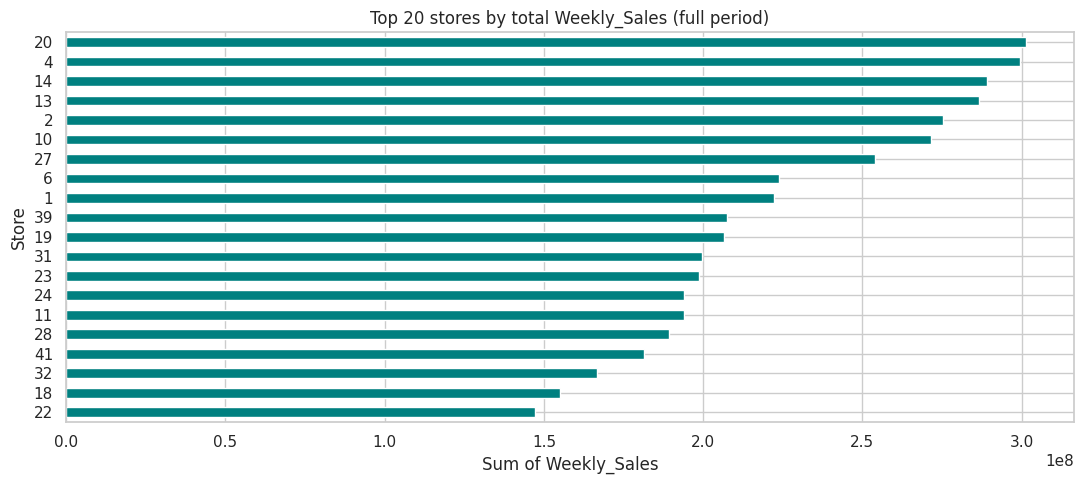

In [22]:
store_sales = df.groupby("Store")["Weekly_Sales"].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(11, 5))
store_sales.head(20).iloc[::-1].plot(kind="barh", ax=ax, color="teal")
ax.set_title("Top 20 stores by total Weekly_Sales (full period)")
ax.set_xlabel("Sum of Weekly_Sales")
plt.tight_layout()
plt.show()

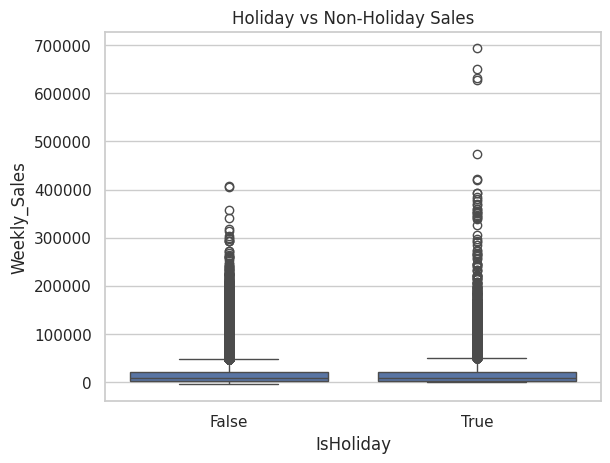

In [23]:
sns.boxplot(x='IsHoliday', y='Weekly_Sales', data=df)
plt.title("Holiday vs Non-Holiday Sales")
plt.show()

## Train-Test Split

In [24]:
TEST_HORIZON = 12

# No missing weeks so asfreq("W-FRI") -> If any Friday were missing, this would insert NaN for that week.
y_full = weekly_totals.set_index("Date")["Weekly_Sales_sum"].asfreq("W-FRI")
if y_full.isna().any():
    # Handle Missing Values interpolate fills them using neighboring values
    y_full = y_full.interpolate(limit_direction="both")

I aggregated store-level data into a single weekly time series to simplify forecasting.

In [25]:
y_train = y_full.iloc[:-TEST_HORIZON]
y_test = y_full.iloc[-TEST_HORIZON:]

print("Train:", y_train.index[0], "→", y_train.index[-1], "|", len(y_train), "weeks")
print("Test: ", y_test.index[0], "→", y_test.index[-1], "|", len(y_test), "weeks")

Train: 2010-02-05 00:00:00 → 2012-08-03 00:00:00 | 131 weeks
Test:  2012-08-10 00:00:00 → 2012-10-26 00:00:00 | 12 weeks


In [26]:
def regression_metrics(y_true, y_pred):
  y_true = np.asarray(y_true, dtype=float)
  y_pred = np.asarray(y_pred, dtype=float)
  mask = y_true != 0
  if mask.any():
      mape = float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)
  else:
      mape = float("nan")
  return {
      "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
      "MAE": float(mean_absolute_error(y_true, y_pred)),
      "MAPE_%": mape,
      "R2":r2_score(y_true, y_pred)
  }

## Stationarity Check

In [27]:
def adf(x):
  res = adfuller(x)
  print("Test-Statistic:", res[0])
  print("P-Value:", res[1])
  if res[1] < 0.05:
    print("Stationary") # I am 95% confident that the series is stationary
  else:
    print("Non-Stationary")

In [28]:
adf(y_train)

Test-Statistic: -5.667865856980573
P-Value: 9.063916855404282e-07
Stationary


<Axes: xlabel='Date'>

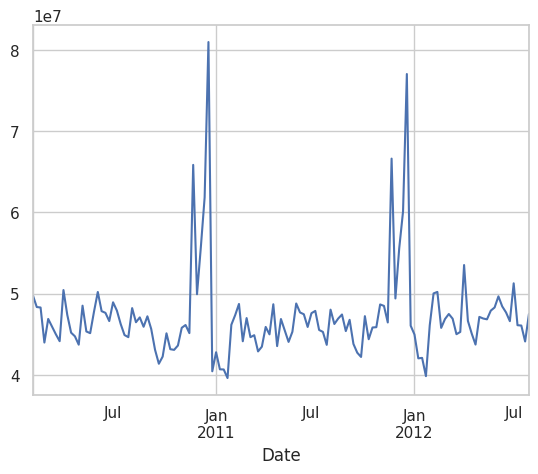

In [29]:
y_train.plot()

## ACF & PACF for non-seasonal parameters p,d,q

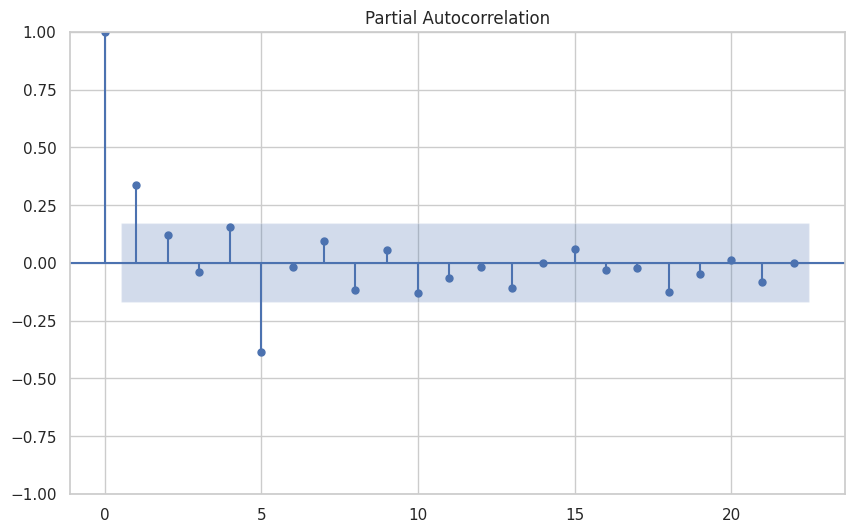

In [30]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_pacf(y_train, ax=ax);

- Lag 1 is clearly outside the band → an AR(1) term is plausible → try p = 1.
- Parsimonious start: p = 1. If residuals still look bad, try p = 2 or p = 5 only if AIC/BIC or CV clearly improve (high p with little data risks overfitting).

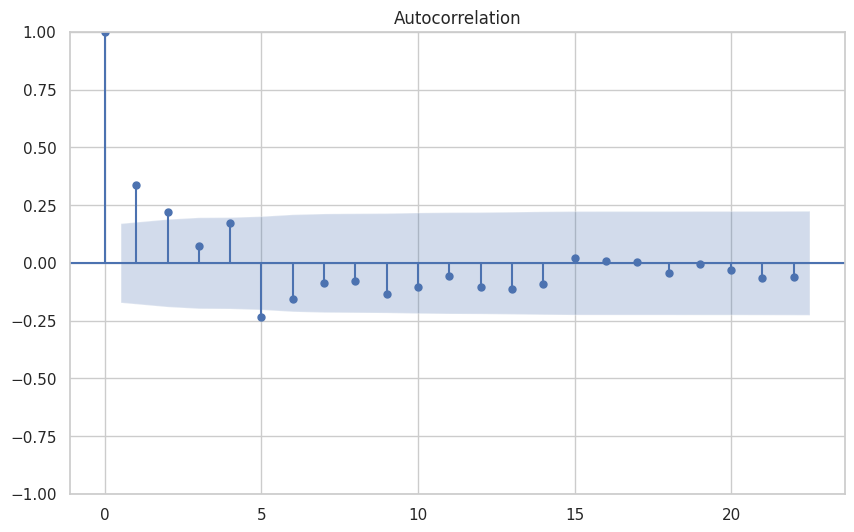

In [31]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_acf(y_train, ax=ax);

- Significant spikes at lags 1, 2, 4, 5 (roughly)
- **Parsimonious** start: q = 1, then maybe q = 2.

## ACF & PACF for seasonal parameters P,D,Q

One year ≈ 52 weeks (sometimes 53 in calendar math, but in time-series practice people almost always use m = 52 as the seasonal period for weekly data).
- So in SARIMAX, seasonal_order=(P, D, Q, 52) means: “seasonal AR/MA and seasonal differencing operate at a 52-week lag,” i.e. annual seasonality in weekly units.
- If the data were monthly, you’d use m = 12. If daily with strong weekly pattern, often m = 7.

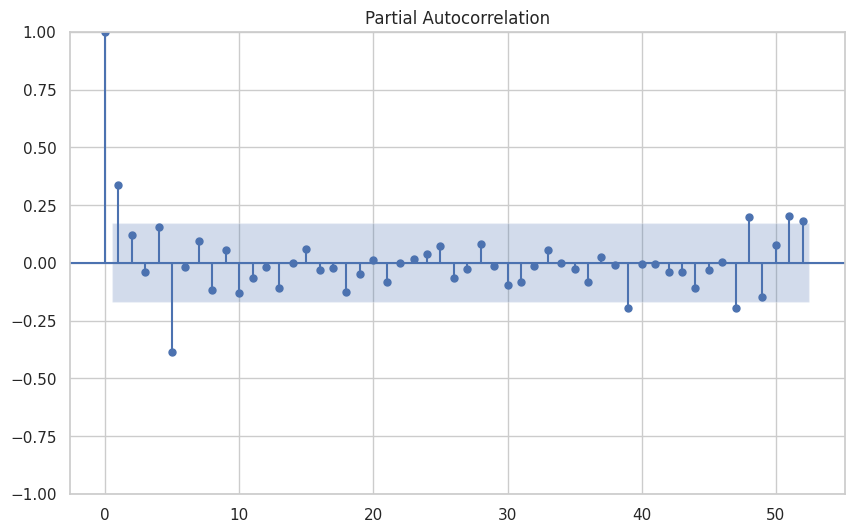

In [32]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_pacf(y_train, ax=ax, lags=52);

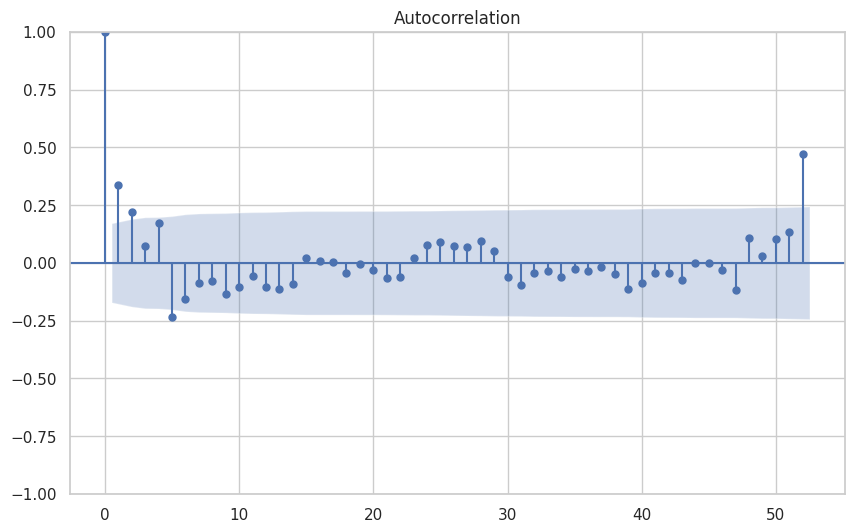

In [33]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_acf(y_train, ax=ax, lags=52);

In [34]:
y_train

,Weekly_Sales_sum
Date,
2010-02-05,49750740.50
2010-02-12,48336677.63
2010-02-19,48276993.78
2010-02-26,43968571.13
2010-03-05,46871470.30
...,...
2012-07-06,51253021.88
2012-07-13,46099732.10
2012-07-20,46059543.45


## ARIMA(Manual)

In [35]:
order = (1, 1, 1)
seasonal_order = (1, 0, 1, 52)

sarima = SARIMAX(
    y_train,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarima_res = sarima.fit(disp=False)
print(sarima_res.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                     SARIMAX Results                                      
Dep. Variable:                   Weekly_Sales_sum   No. Observations:                  131
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 52)   Log Likelihood               -1256.917
Date:                            Tue, 14 Apr 2026   AIC                           2523.833
Time:                                    15:52:30   BIC                           2535.487
Sample:                                02-05-2010   HQIC                          2528.491
                                     - 08-03-2012                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2573      0.873      0.295      0.768      -1.454       1.968
ma.L1         -0.9174      0.624   

In [36]:
# out of sample forecasting
pred_arima = sarima_res.get_forecast(steps=TEST_HORIZON)
fc_arima = pred_arima.predicted_mean
fc_arima.index = y_test.index
print(regression_metrics(y_test, fc_arima))

{'RMSE': 1980871.1539087454, 'MAE': 1612215.6494239687, 'MAPE_%': 3.561215410019599, 'R2': -0.7676328051403738}


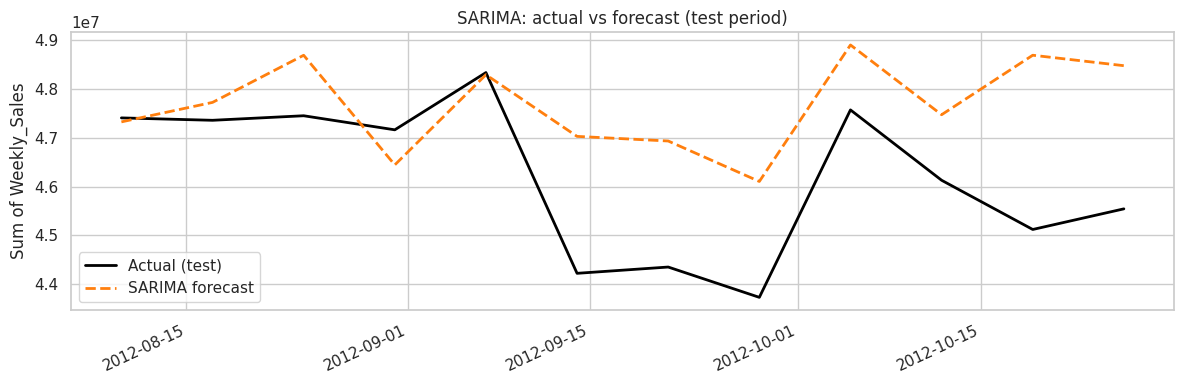

In [37]:
# Plot 1 — test period: actual vs SARIMA forecast
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(y_test.index, y_test, label="Actual (test)", color="black", linewidth=2)
ax.plot(fc_arima.index, fc_arima, label="SARIMA forecast", color="tab:orange", linestyle="--", linewidth=2)
ax.set_title("SARIMA: actual vs forecast (test period)")
ax.set_ylabel("Sum of Weekly_Sales")
ax.legend(loc="best")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

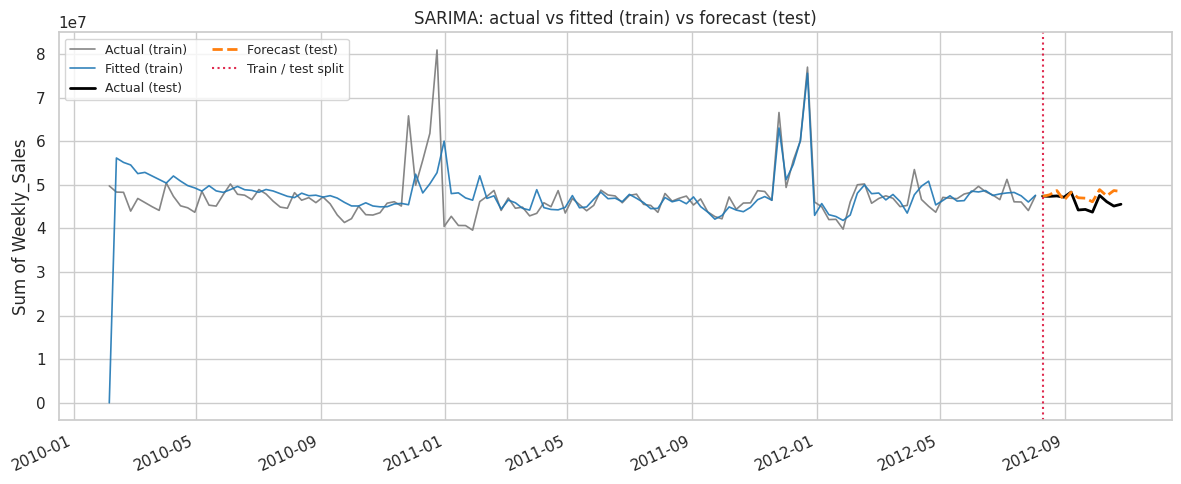

In [38]:
# Plot 2 — train: actual vs fitted; test: actual vs forecast
fitted_arima = sarima_res.fittedvalues

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(y_train.index, y_train, label="Actual (train)", color="gray", linewidth=1.2, alpha=0.95)
ax.plot(fitted_arima.index, fitted_arima, label="Fitted (train)", color="tab:blue", linewidth=1.2, alpha=0.9)
ax.plot(y_test.index, y_test, label="Actual (test)", color="black", linewidth=2)
ax.plot(fc_arima.index, fc_arima, label="Forecast (test)", color="tab:orange", linestyle="--", linewidth=2)
ax.axvline(y_test.index[0], color="crimson", linestyle=":", linewidth=1.5, alpha=0.9, label="Train / test split")
ax.set_title("SARIMA: actual vs fitted (train) vs forecast (test)")
ax.set_ylabel("Sum of Weekly_Sales")
ax.legend(loc="best", ncol=2, fontsize=9)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## Auto-ARIMA

In [39]:
aa = auto_arima(
    y_train,
    seasonal=True,
    m=52,
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore",
    max_p=3,
    max_q=3,
    max_P=2,
    max_Q=2,
    max_order=8,
    maxiter=50,
)
print(aa.summary())

                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                  131
Model:             SARIMAX(2, 0, 2)x(1, 0, [], 52)   Log Likelihood               -2184.013
Date:                             Tue, 14 Apr 2026   AIC                           4382.026
Time:                                     15:56:53   BIC                           4402.153
Sample:                                 02-05-2010   HQIC                          4390.205
                                      - 08-03-2012                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   3.109e+07   1.86e-08   1.67e+15      0.000    3.11e+07    3.11e+07
ar.L1         -0.7934      

In [40]:
fc_auto = pd.Series(aa.predict(n_periods=TEST_HORIZON), index=y_test.index)
print(regression_metrics(y_test, fc_auto))

{'RMSE': 872634.8704291511, 'MAE': 706892.4229973002, 'MAPE_%': 1.521166187845513, 'R2': 0.6569600311052635}


- MAPE ~1.5% is strong on this scale: typical error is about 1.5% of the actual weekly national total.
- RMSE/MAE are still “large” in raw units because the series is tens of millions per week — same idea as before: big numbers, small relative error.

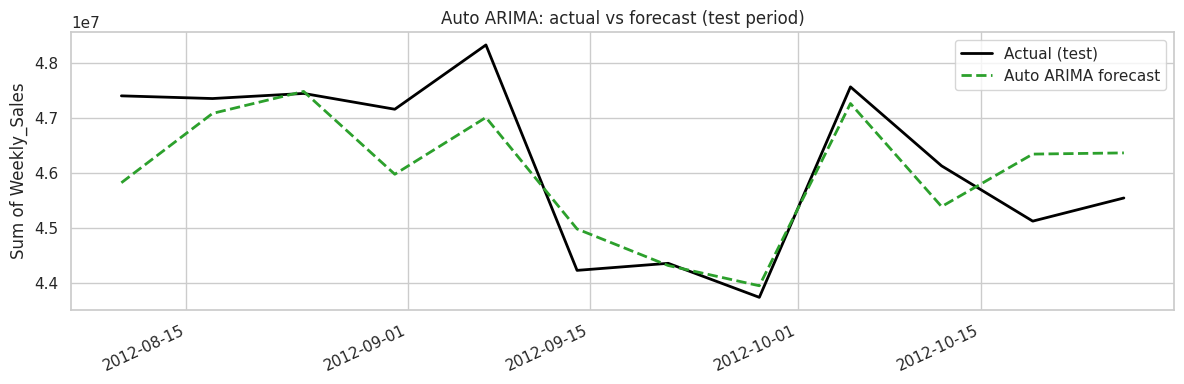

In [41]:
# Plot 1 — Auto ARIMA: test period actual vs forecast
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(y_test.index, y_test, label="Actual (test)", color="black", linewidth=2)
ax.plot(fc_auto.index, fc_auto, label="Auto ARIMA forecast", color="tab:green", linestyle="--", linewidth=2)
ax.set_title("Auto ARIMA: actual vs forecast (test period)")
ax.set_ylabel("Sum of Weekly_Sales")
ax.legend(loc="best")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

The forecast is smoother than the actual line. That is expected: the model summarizes dynamics and does not reproduce every spike. MAPE ~1.5% can still coexist with visible gaps on big swings (e.g. mid-Sept peak)

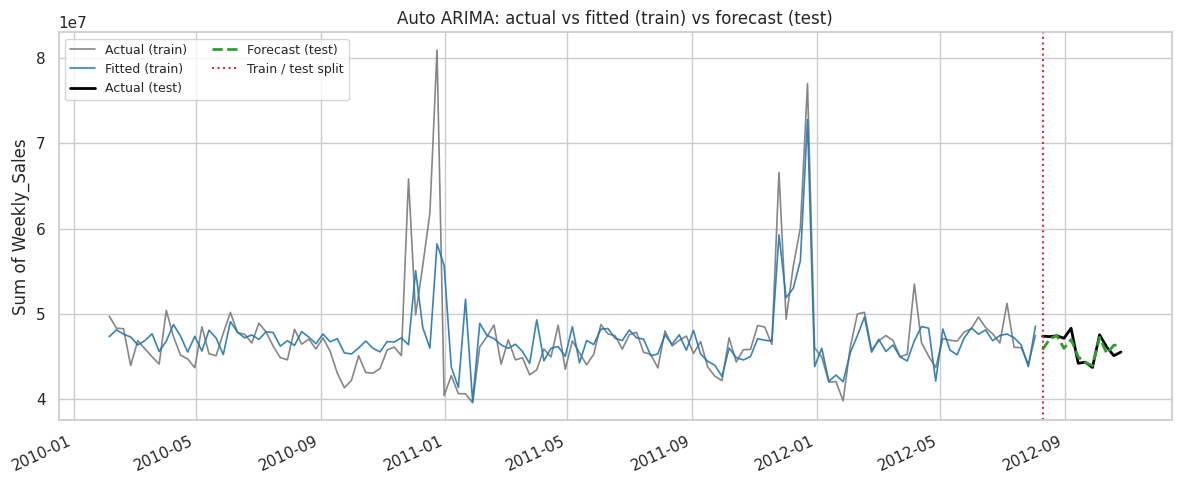

In [42]:
# Plot 2 — Auto ARIMA: train actual vs fitted; test actual vs forecast
in_sample_auto = np.asarray(aa.predict_in_sample(), dtype=float).ravel()
fitted_auto = pd.Series(in_sample_auto, index=y_train.index[-len(in_sample_auto) :])

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(y_train.index, y_train, label="Actual (train)", color="gray", linewidth=1.2, alpha=0.95)
ax.plot(fitted_auto.index, fitted_auto, label="Fitted (train)", color="tab:blue", linewidth=1.2, alpha=0.9)
ax.plot(y_test.index, y_test, label="Actual (test)", color="black", linewidth=2)
ax.plot(fc_auto.index, fc_auto, label="Forecast (test)", color="tab:green", linestyle="--", linewidth=2)
ax.axvline(y_test.index[0], color="crimson", linestyle=":", linewidth=1.5, alpha=0.9, label="Train / test split")
ax.set_title("Auto ARIMA: actual vs fitted (train) vs forecast (test)")
ax.set_ylabel("Sum of Weekly_Sales")
ax.legend(loc="best", ncol=2, fontsize=9)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

On the train segment, blue (fitted) broadly follows gray but can miss the very top of holiday peaks (underfit of extremes). After the red split, green vs black tracking well matches the low MAPE.

`pmdarima.auto_arima` selected SARIMAX(2,0,2)×(1,0,0,52) on y_train, with weekly seasonality `m=52`; on the held-out test window, forecasts achieved MAPE ≈ 1.5%, outperforming our fixed SARIMAX(1,1,1)×(1,0,1,52) specification.

## Prophet

In [43]:
prophet_df = weekly_totals.rename(columns={"Date":"ds", "Weekly_Sales_sum":"y"}).copy()
prophet_df["holiday_week"] = prophet_df["IsHoliday"].astype(int)

In [44]:
prophet_df

,ds,y,IsHoliday,holiday_week
0,2010-02-05,49750740.50,False,0
1,2010-02-12,48336677.63,True,1
2,2010-02-19,48276993.78,False,0
3,2010-02-26,43968571.13,False,0
4,2010-03-05,46871470.30,False,0
...,...,...,...,...
138,2012-09-28,43734899.40,False,0
139,2012-10-05,47566639.31,False,0
140,2012-10-12,46128514.25,False,0
141,2012-10-19,45122410.57,False,0


In [45]:
train_pf = prophet_df.iloc[:-TEST_HORIZON]
test_pf = prophet_df.iloc[-TEST_HORIZON:]

In [46]:
m = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
)
m.add_regressor("holiday_week")
m.fit(train_pf[["ds", "y", "holiday_week"]])

In [47]:
future = test_pf[["ds", "holiday_week"]].copy()
fc_pf = m.predict(future)
fc_prophet = fc_pf.set_index("ds")["yhat"].reindex(y_test.index)
print(regression_metrics(y_test, fc_prophet))

{'RMSE': 986847.018491092, 'MAE': 813201.2687203413, 'MAPE_%': 1.7477815578536833, 'R2': 0.5612882520393455}


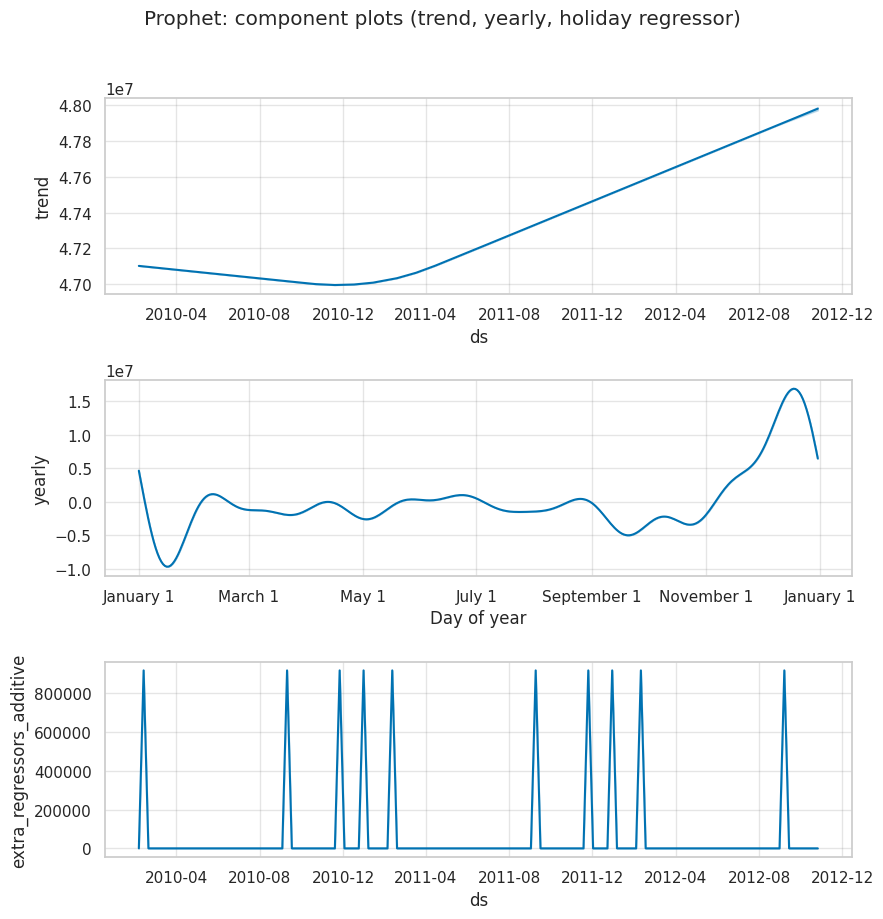

In [48]:
# Prophet: full-sample prediction (needed for component & changepoint plots)
forecast_all = m.predict(prophet_df[["ds", "holiday_week"]])

fig_comp = m.plot_components(forecast_all)
fig_comp.suptitle("Prophet: component plots (trend, yearly, holiday regressor)", y=1.02)
plt.tight_layout()
plt.show()

In [49]:
m_a = Prophet(
    changepoint_prior_scale=0.05,
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
    )
m_a.add_regressor("holiday_week")
m_a.fit(train_pf[["ds", "y", "holiday_week"]])

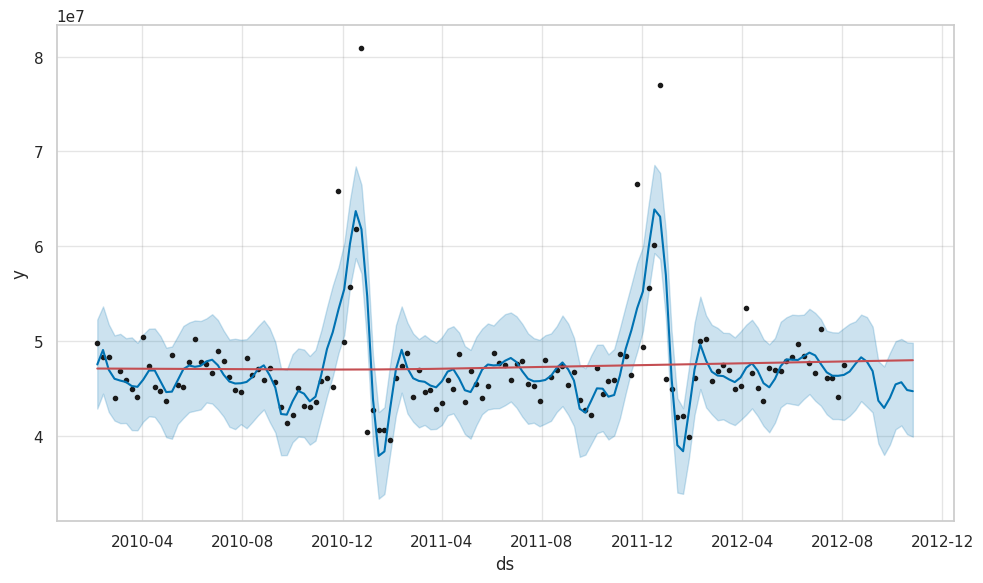

In [50]:
forecast_all = m_a.predict(prophet_df[["ds", "holiday_week"]])

fig = m_a.plot(forecast_all)
a = add_changepoints_to_plot(fig.gca(), m_a, forecast_all)
plt.tight_layout()
plt.show()

- Where the blue line follows the dots closely, the model explains that period well.
- Where dots sit outside the band or above the blue line at peaks, the model is conservative on the strongest weeks (common with smooth seasonal terms).

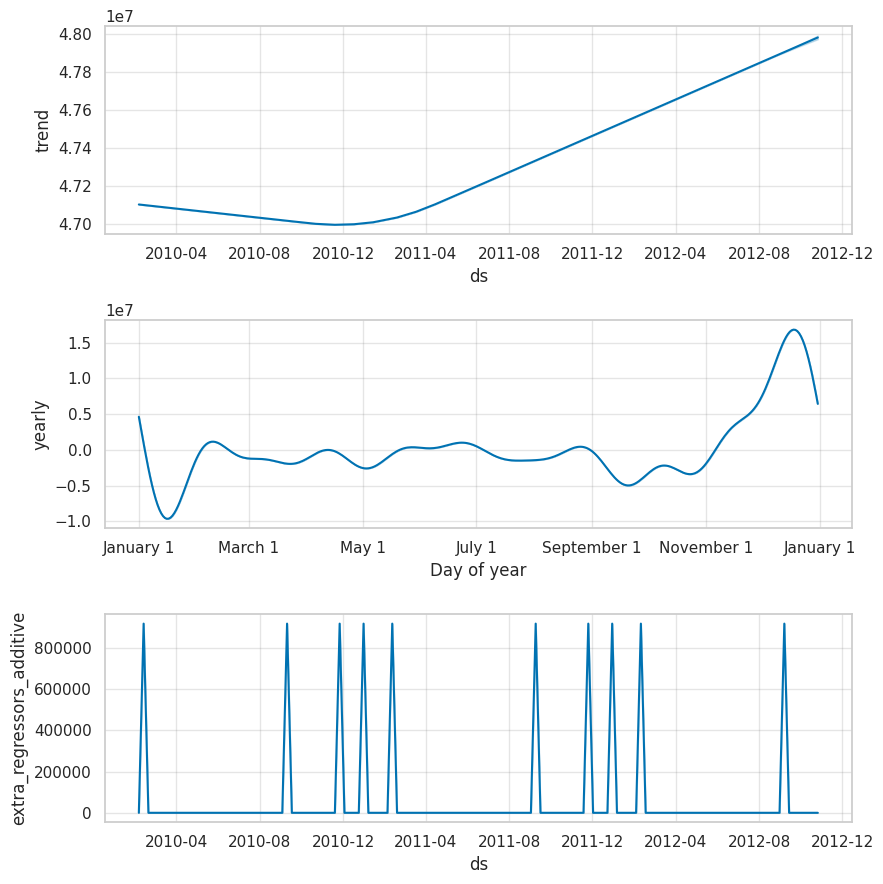

In [51]:
fig_comp = m_a.plot_components(forecast_all)
plt.tight_layout()
plt.show()

In [52]:
compare = pd.DataFrame(
    {
        "actual": y_test,
        "sarima": fc_arima,
        "auto_arima": fc_auto,
        "prophet": fc_prophet,
    }
)

metrics_rows = []
for col in ["sarima", "auto_arima", "prophet"]:
    metrics_rows.append({"model": col, **regression_metrics(compare["actual"], compare[col])})
metrics_df = pd.DataFrame(metrics_rows)
metrics_df

,model,RMSE,MAE,MAPE_%,R2
0,sarima,1.980871e+06,1.612216e+06,3.561215,-0.767633
1,auto_arima,8.726349e+05,7.068924e+05,1.521166,0.656960
2,prophet,9.868470e+05,8.132013e+05,1.747782,0.561288


I evaluated SARIMA, Auto ARIMA, and Prophet using RMSE, MAE, and MAPE. Auto ARIMA performed best with a MAPE of around 1.5%, indicating highly accurate forecasts. Prophet also performed well but slightly underperformed compared to Auto ARIMA. SARIMA had the highest error, suggesting that explicit seasonal modeling did not significantly improve results for this dataset.

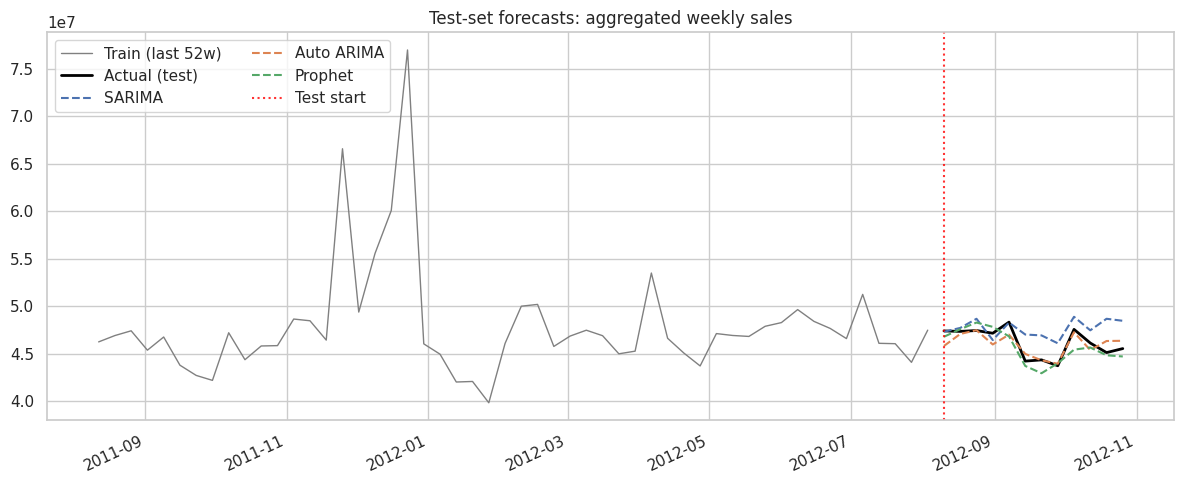

In [53]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(y_train.index[-52:], y_train.iloc[-52:], label="Train (last 52w)", color="gray", linewidth=1)
ax.plot(y_test.index, y_test, label="Actual (test)", color="black", linewidth=2)
ax.plot(compare.index, compare["sarima"], label="SARIMA", linestyle="--")
ax.plot(compare.index, compare["auto_arima"], label="Auto ARIMA", linestyle="--")
ax.plot(compare.index, compare["prophet"], label="Prophet", linestyle="--")
ax.axvline(y_test.index[0], color="red", linestyle=":", alpha=0.8, label="Test start")
ax.set_title("Test-set forecasts: aggregated weekly sales")
ax.legend(loc="best", ncol=2)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

I compared SARIMA, Auto ARIMA, and Prophet on a 12-week holdout set. Auto ARIMA performed best as it closely followed the actual sales trend, while SARIMA slightly overestimated and Prophet showed more variability. All models captured the overall level but struggled with sudden fluctuations, indicating possible external factors like holidays or promotions.

## Log Transformation

Original series stats:
  Mean: 47,113,419  |  Std: 5,444,206  |  Skew: 3.671
Log-transformed series stats:
  Mean: 17.6627  |  Std: 0.0991  |  Skew: 2.834


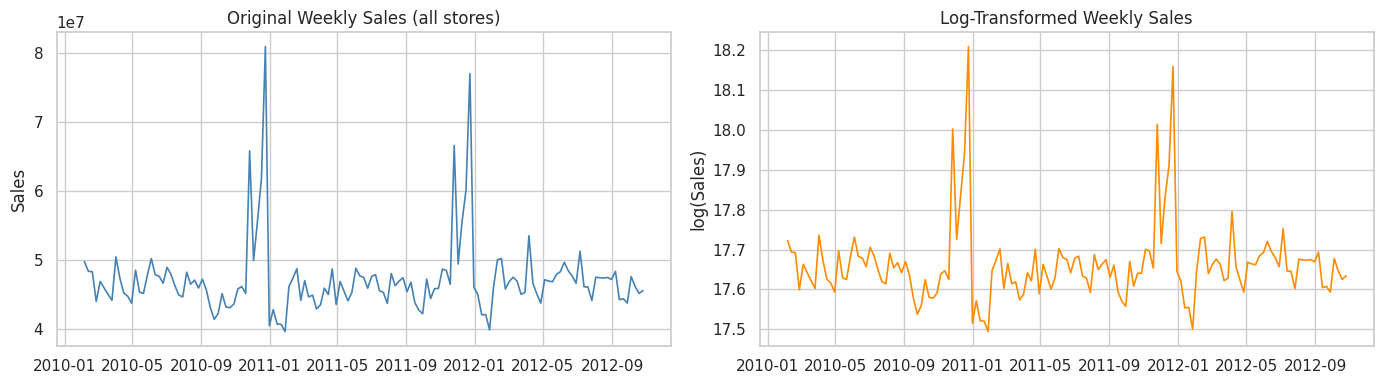

In [54]:
# ── Log Transformation on Overall Sales ─────────────────────────────────────

# Apply log transform to the full series
y_log = np.log(y_full)

print("Original series stats:")
print(f"  Mean: {y_full.mean():,.0f}  |  Std: {y_full.std():,.0f}  |  Skew: {y_full.skew():.3f}")
print("Log-transformed series stats:")
print(f"  Mean: {y_log.mean():.4f}  |  Std: {y_log.std():.4f}  |  Skew: {y_log.skew():.3f}")

#Plot original vs log-transformed
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(y_full.index, y_full, color="steelblue", linewidth=1.2)
axes[0].set_title("Original Weekly Sales (all stores)")
axes[0].set_ylabel("Sales")
axes[1].plot(y_log.index, y_log, color="darkorange", linewidth=1.2)
axes[1].set_title("Log-Transformed Weekly Sales")
axes[1].set_ylabel("log(Sales)")
plt.tight_layout()
plt.show()

In [55]:
#Train/test split on log-transformed series
y_log_train = y_log.iloc[:-TEST_HORIZON]
y_log_test  = y_log.iloc[-TEST_HORIZON:]

print("ADF on log-transformed train series:")
adf(y_log_train)

ADF on log-transformed train series:
Test-Statistic: -6.085622439606997
P-Value: 1.06617010553264e-07
Stationary


### ARIMA Manual

In [56]:
#Manual SARIMA on log-transformed series
sarima_log = SARIMAX(
    y_log_train,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 52),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarima_log_res = sarima_log.fit(disp=False)
print(sarima_log_res.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                     SARIMAX Results                                      
Dep. Variable:                   Weekly_Sales_sum   No. Observations:                  131
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 52)   Log Likelihood                 145.309
Date:                            Tue, 14 Apr 2026   AIC                           -280.617
Time:                                    15:57:03   BIC                           -268.963
Sample:                                02-05-2010   HQIC                          -275.960
                                     - 08-03-2012                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0380      0.161      0.236      0.814      -0.278       0.354
ma.L1         -0.8790      0.072   

In [57]:
# Forecast on log scale, then inverse-transform
fc_log_sarima_log = sarima_log_res.get_forecast(steps=TEST_HORIZON).predicted_mean
fc_log_sarima_log.index = y_test.index
fc_log_sarima = np.exp(fc_log_sarima_log)
print("SARIMA (log):", regression_metrics(y_test, fc_log_sarima))

SARIMA (log): {'RMSE': 612631.0941783434, 'MAE': 513485.1945866477, 'MAPE_%': 1.110032828425559, 'R2': 0.830925672388569}


### Auto Arima

In [58]:
# Auto ARIMA on log-transformed series
aa_log = auto_arima(
    y_log_train,
    seasonal=True, m=52,
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore",
    max_p=3, max_q=3,
    max_P=2, max_Q=2,
    max_order=8,
    maxiter=50,
)
print(aa_log.summary())

                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                  131
Model:             SARIMAX(2, 0, 3)x(1, 0, [], 52)   Log Likelihood                 180.178
Date:                             Tue, 14 Apr 2026   AIC                           -346.356
Time:                                     16:16:40   BIC                           -326.229
Sample:                                 02-05-2010   HQIC                          -338.177
                                      - 08-03-2012                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2153      0.240      0.897      0.369      -0.255       0.686
ar.L2          0.7847      

In [59]:
# Forecast on log scale, then inverse-transform
fc_log_auto_log = pd.Series(aa_log.predict(n_periods=TEST_HORIZON), index=y_test.index)
fc_log_auto = np.exp(fc_log_auto_log)
print("Auto ARIMA (log):", regression_metrics(y_test, fc_log_auto))

Auto ARIMA (log): {'RMSE': 870562.0260177293, 'MAE': 790534.7041868804, 'MAPE_%': 1.7129748345116091, 'R2': 0.6585878000050058}


In [60]:
# Comparison: Original vs Log-Transformed results
m_orig = regression_metrics(y_test, fc_arima)
m_auto_orig = regression_metrics(y_test, fc_auto)
m_log_sarima = regression_metrics(y_test, fc_log_sarima)
m_log_auto = regression_metrics(y_test, fc_log_auto)

results = pd.DataFrame({
    "Model": ["SARIMA (original)", "Auto ARIMA (original)", "SARIMA (log)", "Auto ARIMA (log)"],
    "RMSE":  [round(m_orig["RMSE"], 2),        round(m_auto_orig["RMSE"], 2),
              round(m_log_sarima["RMSE"], 2),   round(m_log_auto["RMSE"], 2)],
    "MAE":   [round(m_orig["MAE"], 2),         round(m_auto_orig["MAE"], 2),
              round(m_log_sarima["MAE"], 2),    round(m_log_auto["MAE"], 2)],
    "MAPE%": [round(m_orig["MAPE_%"], 2),      round(m_auto_orig["MAPE_%"], 2),
              round(m_log_sarima["MAPE_%"], 2), round(m_log_auto["MAPE_%"], 2)],
    "R2":    [round(m_orig["R2"], 3),          round(m_auto_orig["R2"], 3),
              round(m_log_sarima["R2"], 3),     round(m_log_auto["R2"], 3)],
})
print(results.to_string(index=False))

                Model       RMSE        MAE  MAPE%     R2
    SARIMA (original) 1980871.15 1612215.65   3.56 -0.768
Auto ARIMA (original)  872634.87  706892.42   1.52  0.657
         SARIMA (log)  612631.09  513485.19   1.11  0.831
     Auto ARIMA (log)  870562.03  790534.70   1.71  0.659


# Single Store and Single Department

In [61]:
FOCUS_STORE = 1
FOCUS_DEPT = 1

sd = (
    df.loc[(df["Store"] == FOCUS_STORE) & (df["Dept"] == FOCUS_DEPT), ["Date", "Weekly_Sales", "IsHoliday"]]
    .copy()
    .sort_values("Date")
    .reset_index(drop=True)
)
sd["Date"] = pd.to_datetime(sd["Date"])
sd["IsHoliday"] = sd["IsHoliday"].astype(str).str.upper().eq("TRUE")

print(f"Store {FOCUS_STORE}, Dept {FOCUS_DEPT} — rows: {len(sd)}, weeks: {sd['Date'].nunique()}")
sd.head()

Store 1, Dept 1 — rows: 143, weeks: 143


,Date,Weekly_Sales,IsHoliday
0,2010-02-05,24924.50,False
1,2010-02-12,46039.49,True
2,2010-02-19,41595.55,False
3,2010-02-26,19403.54,False
4,2010-03-05,21827.90,False


In [62]:
print("Missing:", sd.isna().sum().to_dict())

Missing: {'Date': 0, 'Weekly_Sales': 0, 'IsHoliday': 0}


## EDA

In [63]:
sd.describe()

,Date,Weekly_Sales
count,143,143.000000
mean,2011-06-17 00:00:00,22513.322937
min,2010-02-05 00:00:00,14537.370000
25%,2010-10-11 12:00:00,16494.630000
50%,2011-06-17 00:00:00,18535.480000
75%,2012-02-20 12:00:00,23214.215000
max,2012-10-26 00:00:00,57592.120000
std,NaN,9854.349032


The dataset contains 143 weekly observations with no missing timestamps. The average weekly sales are around 22K, but the distribution is right-skewed due to occasional high spikes, likely during holidays. The high standard deviation indicates significant variability in sales, suggesting the presence of external factors such as promotions or seasonal demand.

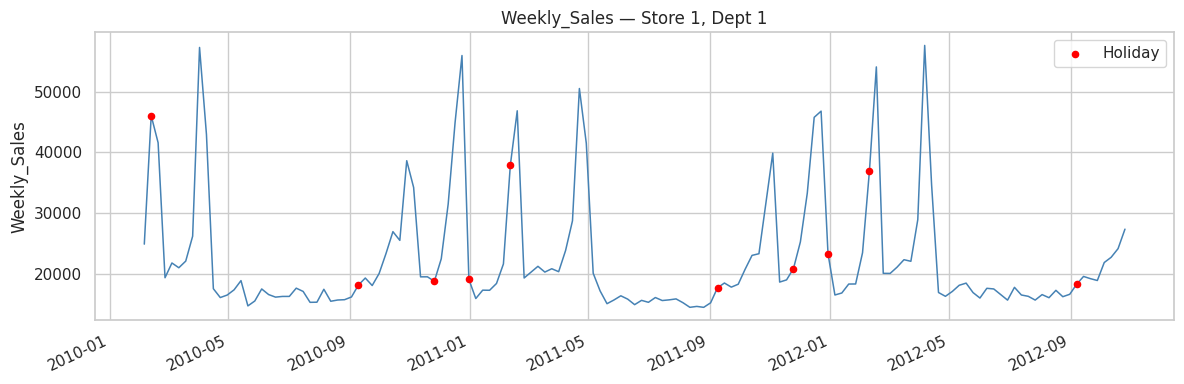

In [64]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(sd["Date"], sd["Weekly_Sales"], color="steelblue", linewidth=1.1)
ax.scatter(
    sd.loc[sd["IsHoliday"], "Date"],
    sd.loc[sd["IsHoliday"], "Weekly_Sales"],
    color="red",
    s=20,
    zorder=5,
    label="Holiday",
)
ax.set_title(f"Weekly_Sales — Store {FOCUS_STORE}, Dept {FOCUS_DEPT}")
ax.set_ylabel("Weekly_Sales")
ax.legend(loc="upper right")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

- The time series shows a stable baseline with no strong long-term trend.
- Significant spikes in sales align with holiday periods, indicating strong external influence on demand.
- Outside of holiday periods, sales remain relatively stable with low variability.
- There is mild annual seasonality driven by recurring holiday events.
- The presence of these spikes introduces non-stationarity and high variance, justifying the use of differencing

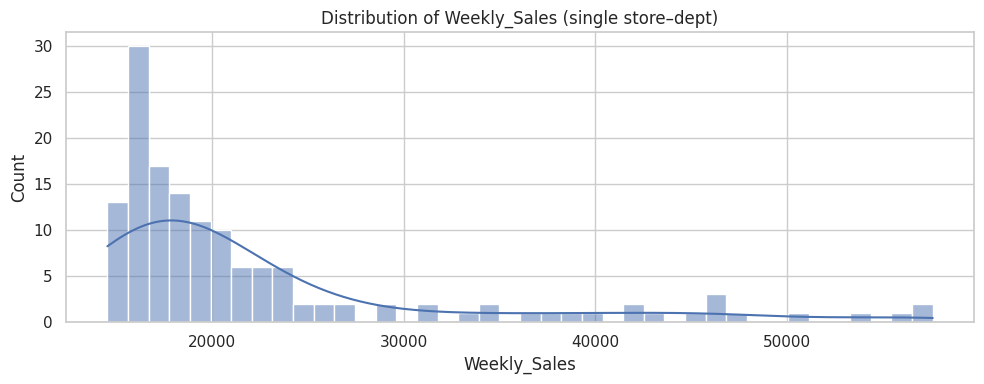

In [65]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(sd["Weekly_Sales"], bins=40, kde=True, ax=ax)
ax.set_title("Distribution of Weekly_Sales (single store–dept)")
plt.tight_layout()
plt.show()

- The distribution is right-skewed, with most values concentrated at lower sales levels and a long tail representing high-sales weeks.
- The distribution of weekly sales is right-skewed, with most values concentrated between 15K and 22K and a long tail extending toward higher values. This indicates that while most weeks have stable demand, occasional spikes—likely during holidays—lead to significantly higher sales. The presence of skewness and outliers suggests that variance is not constant, which may require transformations before applying time series models.”

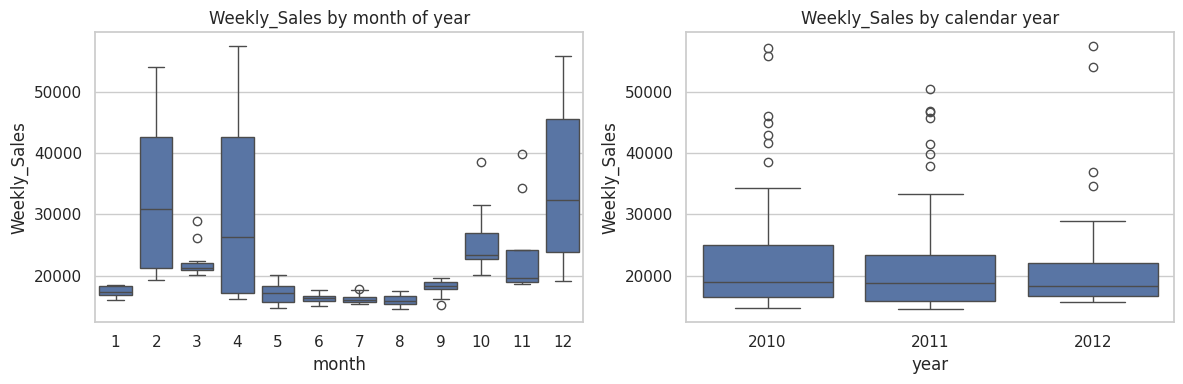

In [66]:
sd_m = sd.assign(month=sd["Date"].dt.month, year=sd["Date"].dt.year)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=sd_m, x="month", y="Weekly_Sales", ax=axes[0])
axes[0].set_title("Weekly_Sales by month of year")
sns.boxplot(data=sd_m, x="year", y="Weekly_Sales", ax=axes[1])
axes[1].set_title("Weekly_Sales by calendar year")
plt.tight_layout()
plt.show()


- The monthly boxplot highlights strong intra-year seasonality, with peak sales occurring in specific months such as February and December, while mid-year months remain stable.
- The yearly boxplot shows consistent distributions across years, indicating no major trend but repeatable seasonal behavior. Together, these suggest that sales are driven more by seasonal events than long-term growth.

/tmp/ipykernel_131113/2599035905.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Non-holiday week", "Holiday week"])


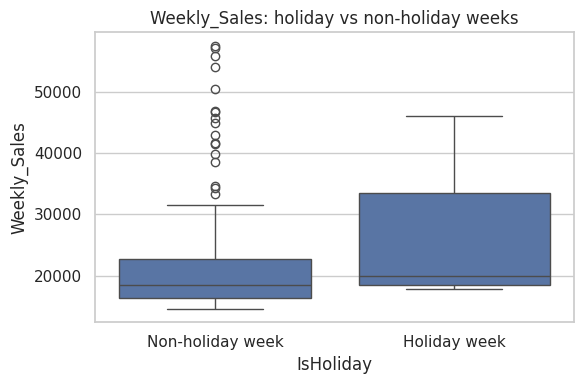

           count      mean    median       std
IsHoliday                                     
False        133  22270.82  18461.18   9806.79
True          10  25738.59  20017.92  10449.18


In [67]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=sd, x="IsHoliday", y="Weekly_Sales", order=[False, True], ax=ax)
ax.set_xticklabels(["Non-holiday week", "Holiday week"])
ax.set_title("Weekly_Sales: holiday vs non-holiday weeks")
plt.tight_layout()
plt.show()
print(sd.groupby("IsHoliday")["Weekly_Sales"].agg(["count", "mean", "median", "std"]).round(2))


Holiday weeks show higher average and median sales compared to non-holiday weeks, confirming their positive impact on demand. However, they also exhibit greater variability, making them harder to predict. Interestingly, some extreme spikes occur outside labeled holidays, suggesting additional external factors such as promotions. This highlights the importance of incorporating external regressors in forecasting models.

## Train-Test Split

In [68]:
# No missing weeks so asfreq("W-FRI") -> If any Friday were missing, this would insert NaN for that week.
y_sd = sd.set_index("Date")["Weekly_Sales"].asfreq("W-FRI")
if y_sd.isna().any():
    # Handle Missing Values interpolate fills them using neighboring values
    y_sd = y_sd.interpolate(limit_direction="both")

In [69]:
y_train_sd = y_sd.iloc[:-TEST_HORIZON]
y_test_sd = y_sd.iloc[-TEST_HORIZON:]
print("Train:", y_train_sd.index[0], "→", y_train_sd.index[-1], "|", len(y_train_sd))
print("Test: ", y_test_sd.index[0], "→", y_test_sd.index[-1], "|", len(y_test_sd))

Train: 2010-02-05 00:00:00 → 2012-08-03 00:00:00 | 131
Test:  2012-08-10 00:00:00 → 2012-10-26 00:00:00 | 12


In [70]:
adf(y_train_sd)

Test-Statistic: -2.3202572568024418
P-Value: 0.165517809638492
Non-Stationary


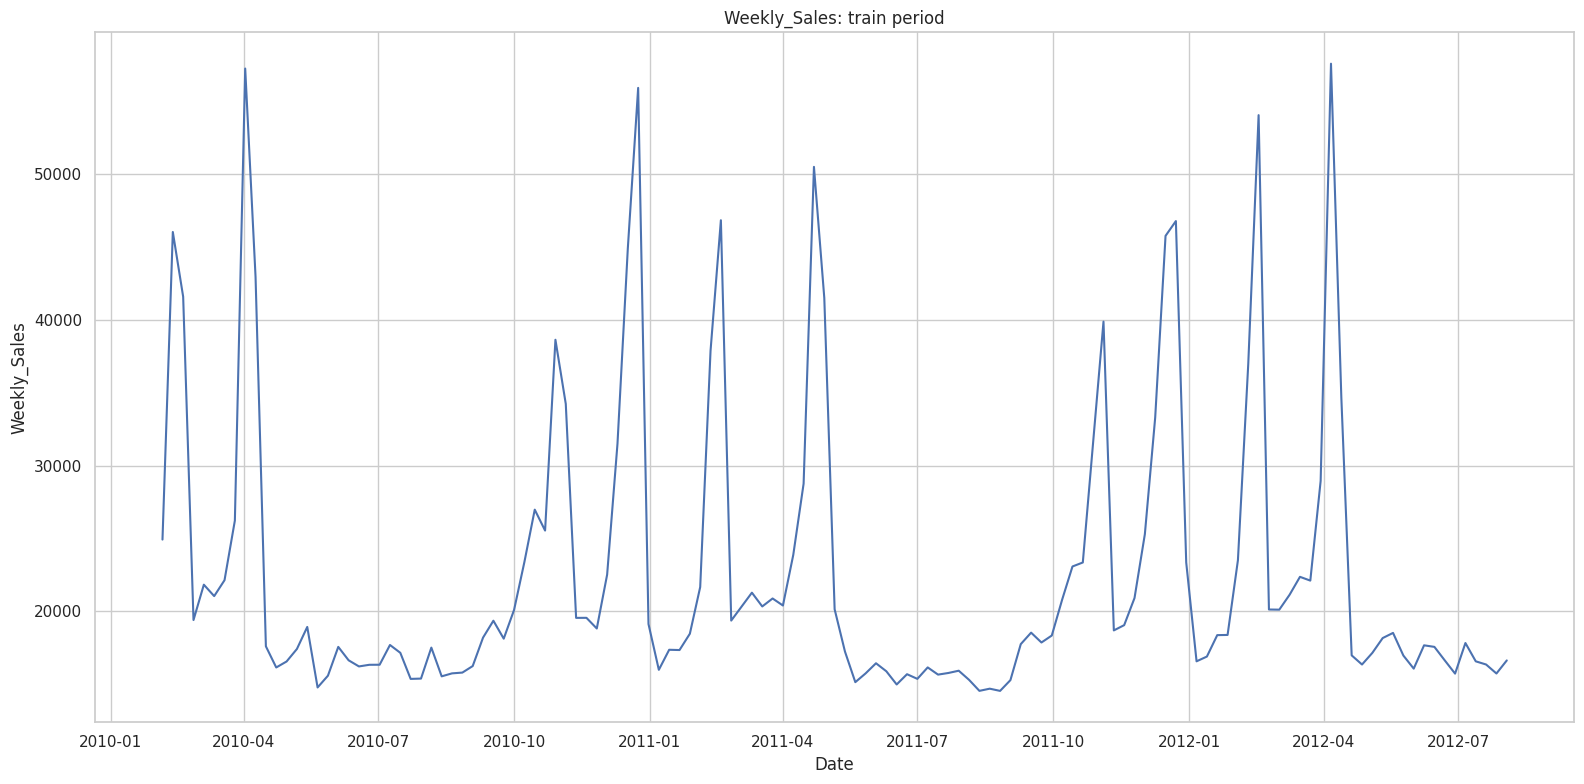

In [71]:
fig, ax = plt.subplots(figsize=(16, 8))
sns.lineplot(x=y_train_sd.index, y=y_train_sd, ax=ax)
ax.set_title("Weekly_Sales: train period")
plt.tight_layout()
plt.show()

In [72]:
y_train_sd_d1 = y_train_sd.diff().dropna()
print("\nADF — first difference (d=1), n =", len(y_train_sd_d1))
adf(y_train_sd_d1)


ADF — first difference (d=1), n = 130
Test-Statistic: -10.635808641165458
P-Value: 5.0760634338400555e-19
Stationary


## ACF & PACF for non-seasonal parameters p,d,q

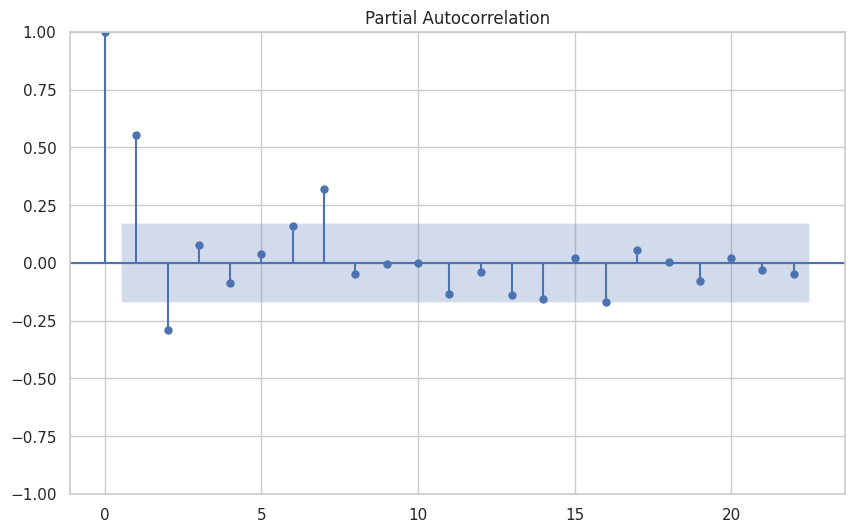

In [73]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_pacf(y_train_sd, ax=ax);

Lags 1 and 2 are clearly outside the band → a reasonable starting guess for AR order is p = 2 (sometimes people try p = 1 if they want a smaller model).

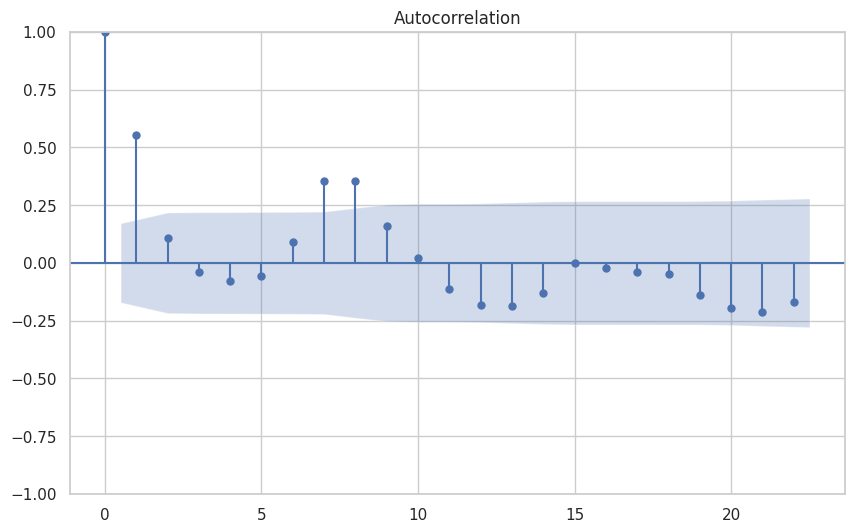

In [74]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_acf(y_train_sd, ax=ax);

Based on the PACF plot, I selected p = 2 as it cuts off after lag 2. The ACF plot shows a gradual decay, so I chose q = 1. Since the series was made stationary using first differencing, d = 1, leading to an ARIMA(2,1,1) model.

## ACF & PACF for seasonal parameters P,D,Q

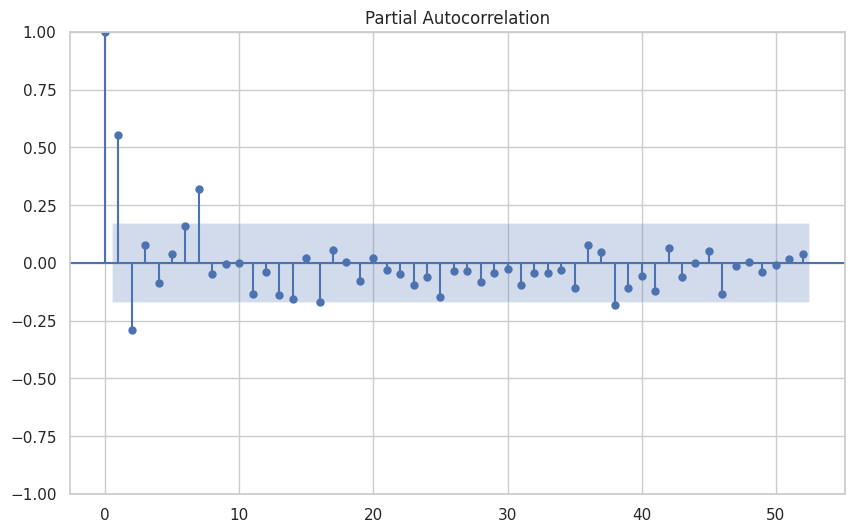

In [75]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_pacf(y_train_sd, ax=ax, lags=52);

The PACF does not show a clear spike at the seasonal lag, suggesting no strong seasonal AR component.

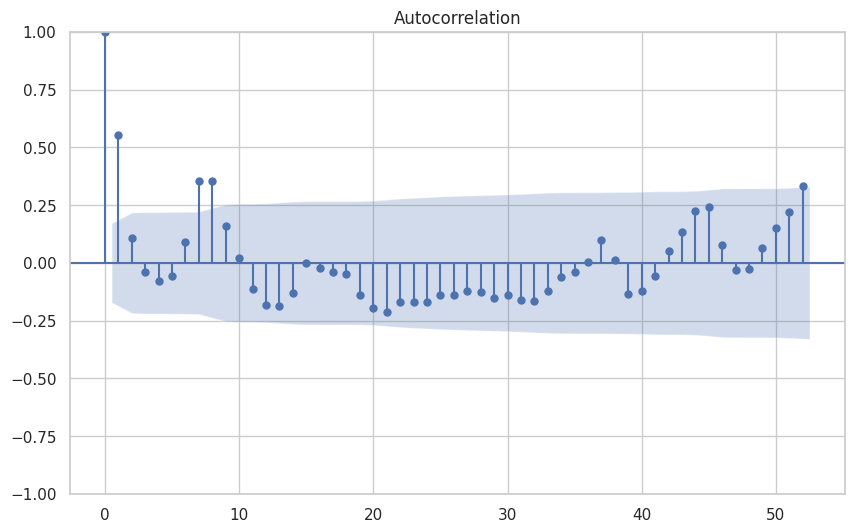

In [76]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_acf(y_train_sd, ax=ax, lags=52);

The ACF plot shows a significant spike at the seasonal lag of 52, suggesting a seasonal MA component of order 1.

From the PACF plot, I observed significant spikes up to lag 2, so I selected p = 2. The ACF showed a gradual decay, so I chose q = 1. Since the series was non-stationary, I applied first differencing, making d = 1. For seasonality, the ACF showed a significant spike at lag 52, indicating a seasonal MA component (Q = 1), while PACF did not show a strong seasonal spike, so P = 0. Given the yearly seasonal pattern, I applied seasonal differencing, so D = 1. Hence, the final model is SARIMA(2,1,1)(0,1,1,52).

In [77]:
y_train_sd

,Weekly_Sales
Date,
2010-02-05,24924.50
2010-02-12,46039.49
2010-02-19,41595.55
2010-02-26,19403.54
2010-03-05,21827.90
...,...
2012-07-06,17823.37
2012-07-13,16566.18
2012-07-20,16348.06


## ARIMA (Manual)

In [78]:
order_sd = (2, 1, 1)
seasonal_order_sd = (0, 1, 1, 52)

sarima_sd = SARIMAX(
    y_train_sd,
    order=order_sd,
    seasonal_order=seasonal_order_sd,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarima_res_sd = sarima_sd.fit(disp=False)
print(sarima_res_sd.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                     SARIMAX Results                                      
Dep. Variable:                       Weekly_Sales   No. Observations:                  131
Model:             SARIMAX(2, 1, 1)x(0, 1, 1, 52)   Log Likelihood                -247.626
Date:                            Tue, 14 Apr 2026   AIC                            505.252
Time:                                    16:16:53   BIC                            511.142
Sample:                                02-05-2010   HQIC                           506.815
                                     - 08-03-2012                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2836      0.379      0.748      0.455      -0.460       1.027
ar.L2         -0.4566      0.327   

In [79]:
fc_arima_sd = sarima_res_sd.get_forecast(steps=TEST_HORIZON).predicted_mean
fc_arima_sd.index = y_test_sd.index
print("SARIMAX:", regression_metrics(y_test_sd, fc_arima_sd))

SARIMAX: {'RMSE': 1789.7271751463181, 'MAE': 1323.7114299277173, 'MAPE_%': 6.187874160975477, 'R2': 0.7150840939719936}


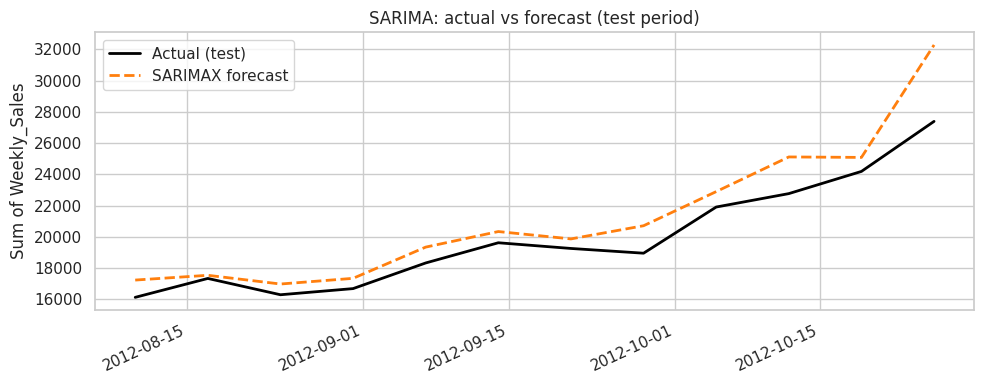

In [80]:
# Plot 1 — test period: actual vs SARIMA forecast
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(y_test_sd.index, y_test_sd, label="Actual (test)", color="black", linewidth=2)
ax.plot(fc_arima_sd.index, fc_arima_sd, label="SARIMAX forecast", color="tab:orange", linestyle="--", linewidth=2)
ax.set_title("SARIMA: actual vs forecast (test period)")
ax.set_ylabel("Sum of Weekly_Sales")
ax.legend(loc="best")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

The SARIMA model captures the overall upward trend in the test period reasonably well, with both the actual (black) and forecast (orange dashed) lines rising from August to October 2012. In the early and mid test period, the forecast runs slightly above the actual values, indicating a modest overestimation. However, the largest divergence occurs in late October, where the forecast overshoots significantly — rising to ~32,000 while actual sales reach ~27,000. This is because the seasonal MA term (lag 52) learned the sharp year-end sales spike from 2010 and 2011, but the 2012 peak was less pronounced, causing the model to over-predict. Despite this, the model achieves MAPE = 6.19% and R² = 0.715, making it the best-performing model for this single store-department combination.

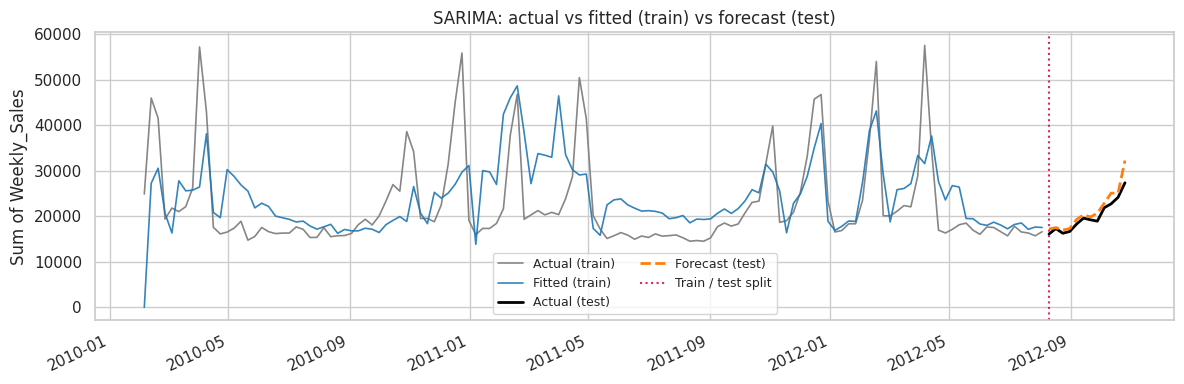

In [81]:
# Plot 2 — train: actual vs fitted; test: actual vs forecast
fitted_arima = sarima_res_sd.fittedvalues

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(y_train_sd.index, y_train_sd, label="Actual (train)", color="gray", linewidth=1.2, alpha=0.95)
ax.plot(fitted_arima.index, fitted_arima, label="Fitted (train)", color="tab:blue", linewidth=1.2, alpha=0.9)
ax.plot(y_test_sd.index, y_test_sd, label="Actual (test)", color="black", linewidth=2)
ax.plot(fc_arima_sd.index, fc_arima_sd, label="Forecast (test)", color="tab:orange", linestyle="--", linewidth=2)
ax.axvline(y_test_sd.index[0], color="crimson", linestyle=":", linewidth=1.5, alpha=0.9, label="Train / test split")
ax.set_title("SARIMA: actual vs fitted (train) vs forecast (test)")
ax.set_ylabel("Sum of Weekly_Sales")
ax.legend(loc="best", ncol=2, fontsize=9)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

The full-period plot gives a clearer picture of how the SARIMA model behaved across both training and test phases. In the training segment (2010–mid 2012), the blue fitted line broadly tracks the gray actual line but consistently misses the sharp holiday spikes — these extreme peaks are difficult for any linear model to reproduce exactly. The red dotted vertical line marks the train/test split. After this point, the black actual line and the orange dashed forecast both rise steadily, confirming that the model correctly identified the upward seasonal trend heading into the year-end period. The forecast overshoots slightly in the final weeks (late October 2012), driven by the seasonal MA(52) term amplifying the year-end pattern beyond what actually occurred in 2012. Overall, the model achieves MAPE = 6.19% and R² = 0.715, making it the best-performing model among SARIMA, Auto ARIMA, and Prophet for this single store-department combination.

## Auto ARIMA

In [82]:
# ── Auto-ARIMA  (Store 1, Dept 1) ────────────────────────────────────────────
aa_sd = auto_arima(
    y_train_sd,
    seasonal=True,
    m=52,
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore",
    max_p=3, max_q=3,
    max_P=2, max_Q=2,
    max_order=8,
    maxiter=50,
)
print(aa_sd.summary())

                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                  131
Model:             SARIMAX(1, 0, 1)x(1, 0, [], 52)   Log Likelihood               -1354.202
Date:                             Tue, 14 Apr 2026   AIC                           2718.404
Time:                                     16:19:18   BIC                           2732.780
Sample:                                 02-05-2010   HQIC                          2724.245
                                      - 08-03-2012                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   1.284e+04   4453.096      2.884      0.004    4114.438    2.16e+04
ar.L1          0.0761      

In [83]:
# Forecast on test set & regression metrics
fc_auto_sd = pd.Series(aa_sd.predict(n_periods=TEST_HORIZON), index=y_test_sd.index)
print("Auto-ARIMA:", regression_metrics(y_test_sd, fc_auto_sd))

Auto-ARIMA: {'RMSE': 2209.4241025852407, 'MAE': 1938.6920922711327, 'MAPE_%': 10.76106143831932, 'R2': 0.5657886162154371}


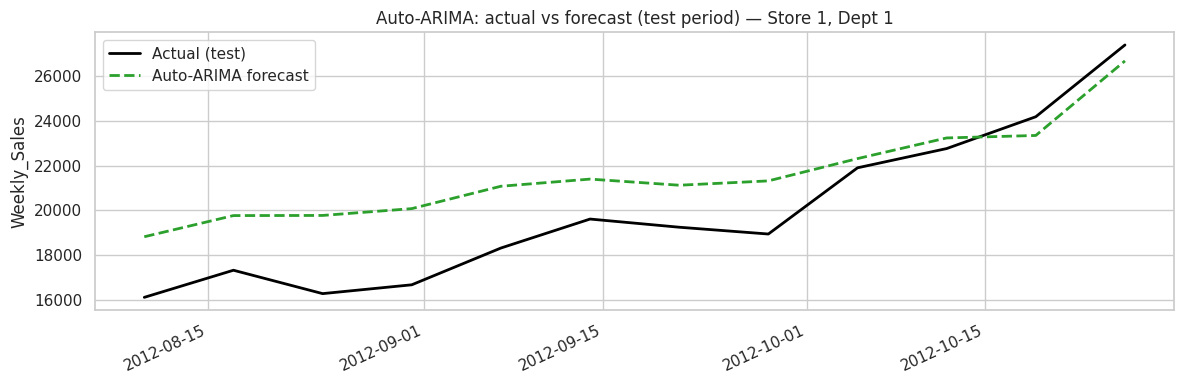

In [84]:
# Plot 1 — test period: actual vs Auto-ARIMA forecast
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(y_test_sd.index, y_test_sd, label="Actual (test)", color="black", linewidth=2)
ax.plot(fc_auto_sd.index, fc_auto_sd, label="Auto-ARIMA forecast", color="tab:green", linestyle="--", linewidth=2)
ax.set_title(f"Auto-ARIMA: actual vs forecast (test period) — Store {FOCUS_STORE}, Dept {FOCUS_DEPT}")
ax.set_ylabel("Weekly_Sales")
ax.legend(loc="best")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

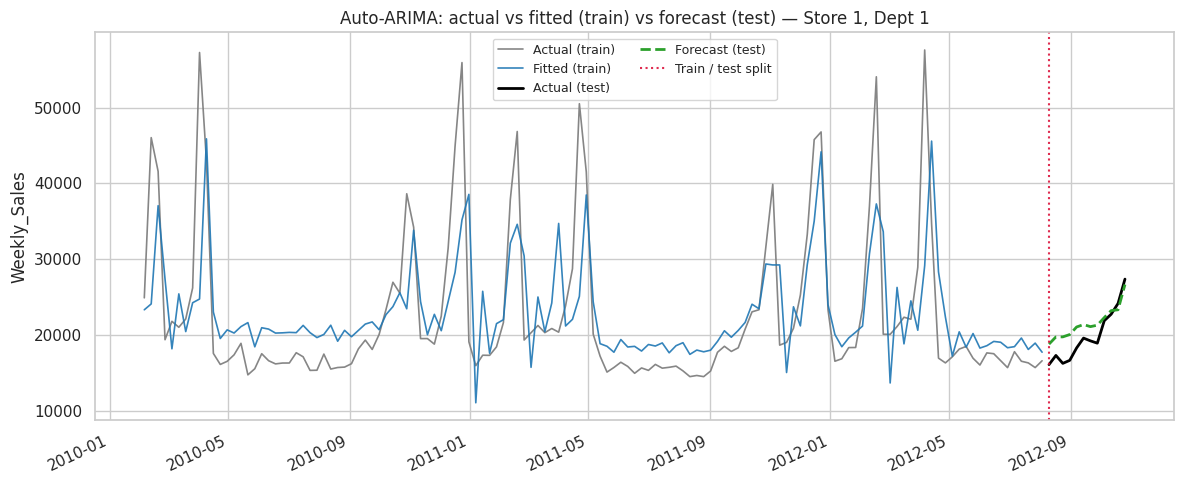

In [85]:
# Plot 2 — train: actual vs fitted; test: actual vs forecast
in_sample_auto_sd = np.asarray(aa_sd.predict_in_sample(), dtype=float).ravel()
fitted_auto_sd = pd.Series(in_sample_auto_sd, index=y_train_sd.index[-len(in_sample_auto_sd):])

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(y_train_sd.index, y_train_sd, label="Actual (train)", color="gray", linewidth=1.2, alpha=0.95)
ax.plot(fitted_auto_sd.index, fitted_auto_sd, label="Fitted (train)", color="tab:blue", linewidth=1.2, alpha=0.9)
ax.plot(y_test_sd.index, y_test_sd, label="Actual (test)", color="black", linewidth=2)
ax.plot(fc_auto_sd.index, fc_auto_sd, label="Forecast (test)", color="tab:green", linestyle="--", linewidth=2)
ax.axvline(y_test_sd.index[0], color="crimson", linestyle=":", linewidth=1.5, alpha=0.9, label="Train / test split")
ax.set_title(f"Auto-ARIMA: actual vs fitted (train) vs forecast (test) — Store {FOCUS_STORE}, Dept {FOCUS_DEPT}")
ax.set_ylabel("Weekly_Sales")
ax.legend(loc="best", ncol=2, fontsize=9)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## Prophet

In [86]:
prophet_df_sd = sd.rename(columns={"Date":"ds", "Weekly_Sales":"y"}).copy()
prophet_df_sd["holiday_week"] = prophet_df_sd["IsHoliday"].astype(int)

In [87]:
prophet_df_sd

,ds,y,IsHoliday,holiday_week
0,2010-02-05,24924.50,False,0
1,2010-02-12,46039.49,True,1
2,2010-02-19,41595.55,False,0
3,2010-02-26,19403.54,False,0
4,2010-03-05,21827.90,False,0
...,...,...,...,...
138,2012-09-28,18947.81,False,0
139,2012-10-05,21904.47,False,0
140,2012-10-12,22764.01,False,0
141,2012-10-19,24185.27,False,0


In [88]:
train_pf_sd = prophet_df_sd.iloc[:-TEST_HORIZON]
test_pf_sd = prophet_df_sd.iloc[-TEST_HORIZON:]

In [89]:
# Prophet (Store 1, Dept 1)

#Base Prophet model
m_sd = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
)
m_sd.add_regressor("holiday_week")
m_sd.fit(train_pf_sd[["ds", "y", "holiday_week"]])

# Forecast on test set
future_sd = test_pf_sd[["ds", "holiday_week"]].copy()
fc_pf_sd  = m_sd.predict(future_sd)
fc_prophet_sd = fc_pf_sd.set_index("ds")["yhat"].reindex(y_test_sd.index)
print("Prophet (base):", regression_metrics(y_test_sd, fc_prophet_sd))

Prophet (base): {'RMSE': 2307.9430389839586, 'MAE': 1844.6914900134334, 'MAPE_%': 8.755432311942474, 'R2': 0.5262020225288154}


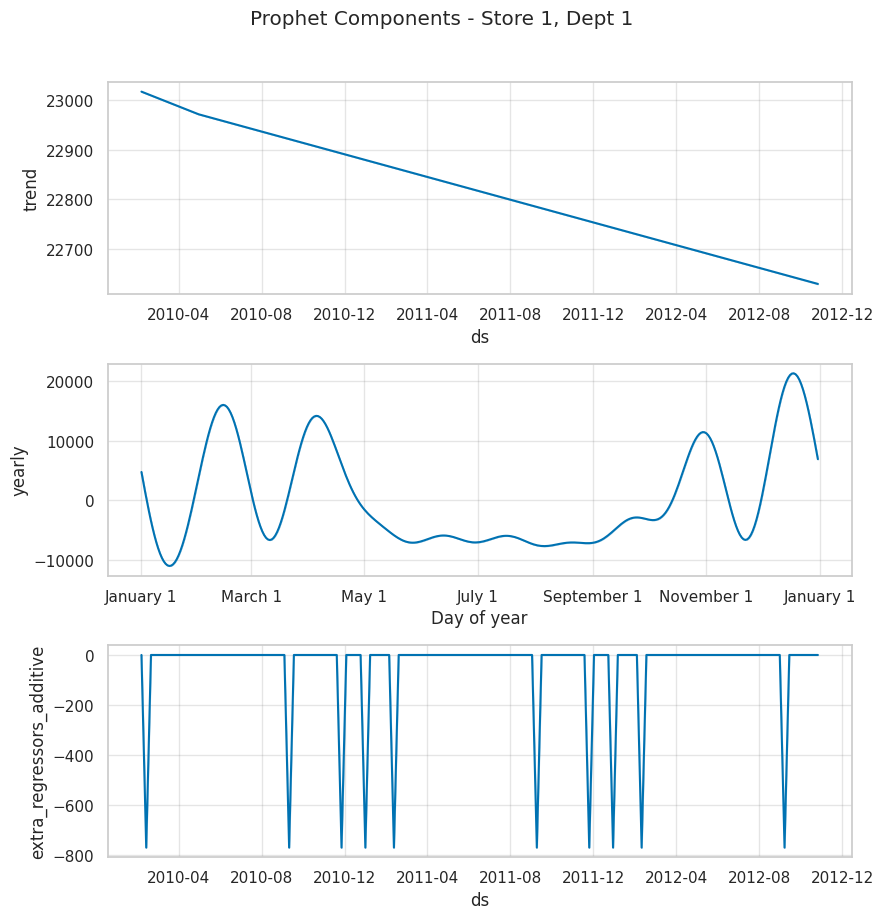

In [90]:
#Components plot
forecast_all_sd = m_sd.predict(prophet_df_sd[["ds", "holiday_week"]])
fig_comp = m_sd.plot_components(forecast_all_sd)
fig_comp.suptitle(
    f"Prophet Components - Store {FOCUS_STORE}, Dept {FOCUS_DEPT}", y=1.02
)
plt.tight_layout()
plt.show()

In [91]:
m_sd_cp = Prophet(
    changepoint_prior_scale=0.05,
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
)
m_sd_cp.add_regressor("holiday_week")
m_sd_cp.fit(train_pf[["ds", "y", "holiday_week"]])

# Forecast on test set with tuned changepoint scale
fc_pf_sd_cp = m_sd_cp.predict(future_sd)
fc_prophet_sd_cp = fc_pf_sd_cp.set_index("ds")["yhat"].reindex(y_test_sd.index)
print("Prophet (changepoint_prior_scale=0.05):\n", regression_metrics(y_test_sd, fc_prophet_sd_cp))

Prophet (changepoint_prior_scale=0.05):
 {'RMSE': 45730183.062865, 'MAE': 45699603.962388605, 'MAPE_%': 236439.5557949372, 'R2': -186015403.19115293}


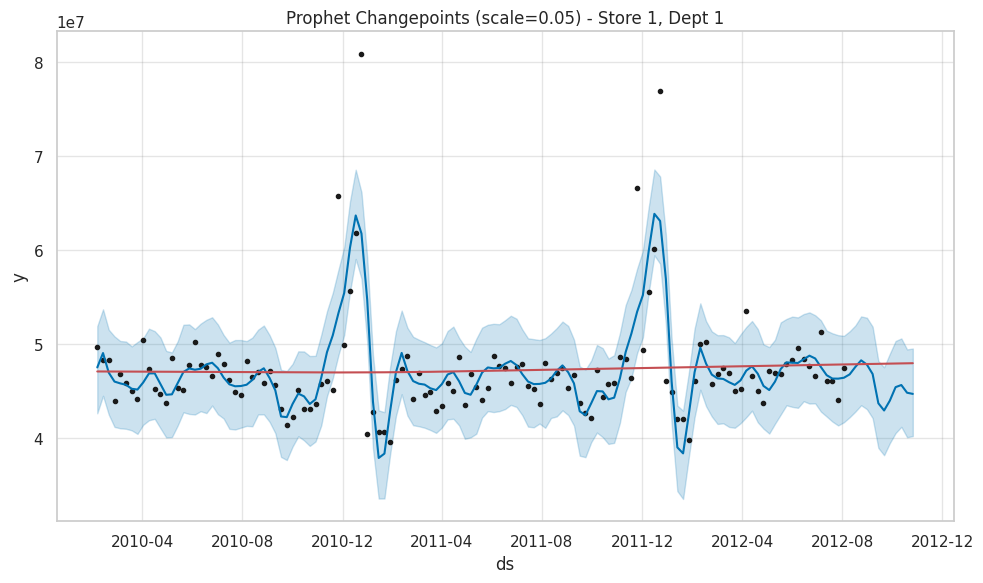

In [92]:
# Changepoints plot
forecast_all_sd_cp = m_sd_cp.predict(prophet_df_sd[["ds", "holiday_week"]])
fig_cp = m_sd_cp.plot(forecast_all_sd_cp)
a = add_changepoints_to_plot(fig_cp.gca(), m_sd_cp, forecast_all_sd_cp)
plt.title(f"Prophet Changepoints (scale=0.05) - Store {FOCUS_STORE}, Dept {FOCUS_DEPT}")
plt.tight_layout()
plt.show()

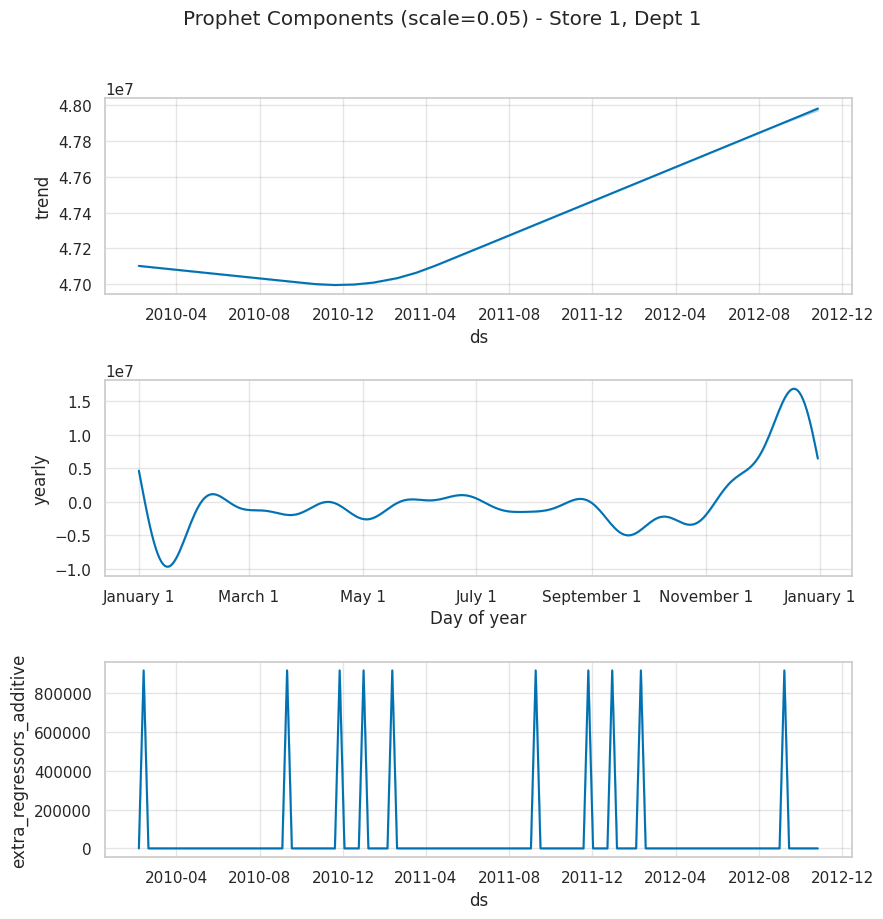

In [93]:
# Components plot for changepoint-tuned model
fig_comp_cp = m_sd_cp.plot_components(forecast_all_sd_cp)
fig_comp_cp.suptitle(f"Prophet Components (scale=0.05) - Store {FOCUS_STORE}, Dept {FOCUS_DEPT}", y=1.02)
plt.tight_layout()
plt.show()

In [94]:
compare = pd.DataFrame(
    {
        "actual": y_test_sd,
        "sarima": fc_arima_sd,
        "auto_arima": fc_auto_sd,
        "prophet": fc_prophet_sd,
    }
)

metrics_rows = []
for col in ["sarima", "auto_arima", "prophet"]:
    metrics_rows.append({"model": col, **regression_metrics(compare["actual"], compare[col])})
metrics_df = pd.DataFrame(metrics_rows)
metrics_df

,model,RMSE,MAE,MAPE_%,R2
0,sarima,1789.727175,1323.711430,6.187874,0.715084
1,auto_arima,2209.424103,1938.692092,10.761061,0.565789
2,prophet,2307.943039,1844.691490,8.755432,0.526202


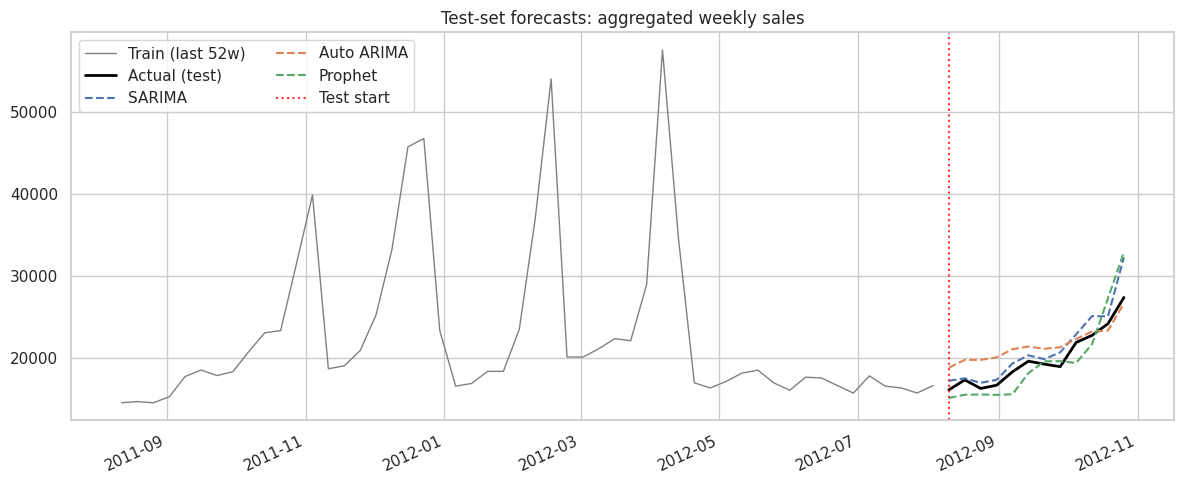

In [95]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(y_train_sd.index[-52:], y_train_sd.iloc[-52:], label="Train (last 52w)", color="gray", linewidth=1)
ax.plot(y_test_sd.index, y_test_sd, label="Actual (test)", color="black", linewidth=2)
ax.plot(compare.index, compare["sarima"], label="SARIMA", linestyle="--")
ax.plot(compare.index, compare["auto_arima"], label="Auto ARIMA", linestyle="--")
ax.plot(compare.index, compare["prophet"], label="Prophet", linestyle="--")
ax.axvline(y_test_sd.index[0], color="red", linestyle=":", alpha=0.8, label="Test start")
ax.set_title("Test-set forecasts: aggregated weekly sales")
ax.legend(loc="best", ncol=2)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## Log Transformation

Original series stats:
  Mean: 22,513  |  Std: 9,854  |  Skew: 2.014
Log-transformed series stats:
  Mean: 9.9534  |  Std: 0.3433  |  Skew: 1.444


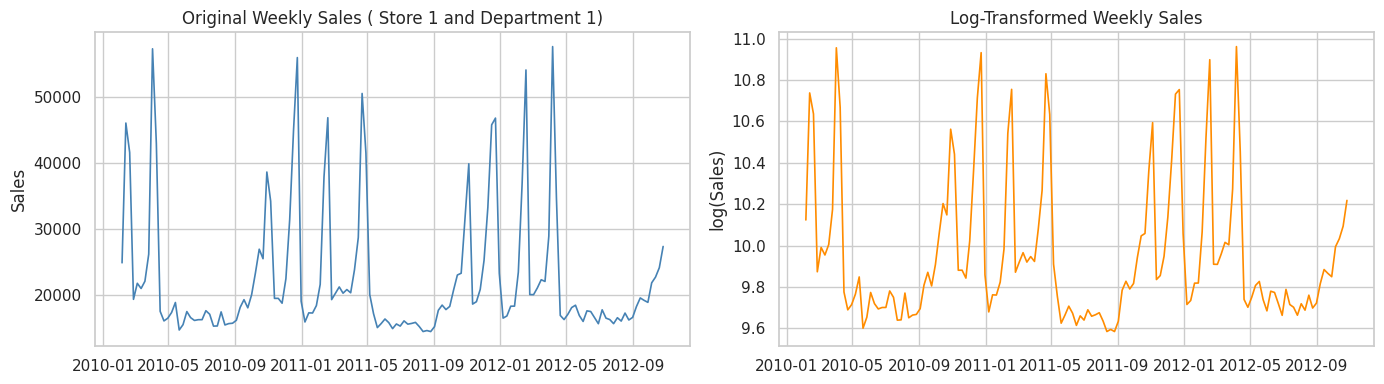

In [96]:
# ── Log Transformation on Overall Sales ─────────────────────────────────────

# Apply log transform to the full series
y_sd_log = np.log(y_sd)

print("Original series stats:")
print(f"  Mean: {y_sd.mean():,.0f}  |  Std: {y_sd.std():,.0f}  |  Skew: {y_sd.skew():.3f}")
print("Log-transformed series stats:")
print(f"  Mean: {y_sd_log.mean():.4f}  |  Std: {y_sd_log.std():.4f}  |  Skew: {y_sd_log.skew():.3f}")

#Plot original vs log-transformed
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(y_sd.index, y_sd, color="steelblue", linewidth=1.2)
axes[0].set_title("Original Weekly Sales ( Store 1 and Department 1)")
axes[0].set_ylabel("Sales")
axes[1].plot(y_sd_log.index, y_sd_log, color="darkorange", linewidth=1.2)
axes[1].set_title("Log-Transformed Weekly Sales")
axes[1].set_ylabel("log(Sales)")
plt.tight_layout()
plt.show()

In [97]:
#Train/test split on log-transformed series
y_sd_log_train = y_sd_log.iloc[:-TEST_HORIZON]
y_sd_log_test  = y_sd_log.iloc[-TEST_HORIZON:]

print("ADF on log-transformed train series:")
adf(y_sd_log_train)

ADF on log-transformed train series:
Test-Statistic: -2.0945271991181955
P-Value: 0.2467209292338453
Non-Stationary


In [98]:
y_sd_log_train_d1 = y_sd_log_train.diff().dropna()
print("\nADF — first difference (d=1), n =", len(y_sd_log_train_d1))
adf(y_sd_log_train_d1)


ADF — first difference (d=1), n = 130
Test-Statistic: -9.942647462707951
P-Value: 2.6393315337158858e-17
Stationary


### ARIMA Manual

In [99]:
#Manual SARIMA on log-transformed series
sarima_sd_log = SARIMAX(
    y_sd_log_train,
    order=(2, 1, 1),
    seasonal_order=(0, 1, 1, 52),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarima_sd_log_res = sarima_sd_log.fit(disp=False)
print(sarima_sd_log_res.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                     SARIMAX Results                                      
Dep. Variable:                       Weekly_Sales   No. Observations:                  131
Model:             SARIMAX(2, 1, 1)x(0, 1, 1, 52)   Log Likelihood                   7.751
Date:                            Tue, 14 Apr 2026   AIC                             -5.503
Time:                                    16:19:34   BIC                              0.388
Sample:                                02-05-2010   HQIC                            -3.940
                                     - 08-03-2012                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3229      0.251      1.288      0.198      -0.169       0.814
ar.L2         -0.5742      0.181   

In [100]:
# Forecast on log scale, then inverse-transform
fc_log_sarima_sd_log = sarima_sd_log_res.get_forecast(steps=TEST_HORIZON).predicted_mean
fc_log_sarima_sd_log.index = y_test_sd.index
fc_log_sarima_sd = np.exp(fc_log_sarima_sd_log)
print("SARIMA (log):", regression_metrics(y_test_sd, fc_log_sarima_sd))

SARIMA (log): {'RMSE': 2509.787356070487, 'MAE': 1500.7742711188394, 'MAPE_%': 6.8889375055587525, 'R2': 0.4397048224418718}


### Auto ARIMA

In [101]:
# Auto ARIMA on log-transformed series
aa_sd_log = auto_arima(
    y_sd_log_train,
    seasonal=True,
    m=52,
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore",
    max_p=3, max_q=3,
    max_P=2, max_Q=2,
    max_order=8,
    maxiter=50,
)
print(aa_sd_log.summary())

                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                  131
Model:             SARIMAX(0, 0, 2)x(2, 0, [], 52)   Log Likelihood                  15.776
Date:                             Tue, 14 Apr 2026   AIC                            -19.552
Time:                                     16:30:06   BIC                             -2.300
Sample:                                 02-05-2010   HQIC                           -12.542
                                      - 08-03-2012                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      3.1978      0.762      4.195      0.000       1.704       4.692
ma.L1          0.9168      

In [102]:
# Forecast on log scale, then inverse-transform
fc_log_auto_sd_log = pd.Series(aa_sd_log.predict(n_periods=TEST_HORIZON), index=y_test_sd.index)
fc_log_auto_sd = np.exp(fc_log_auto_sd_log)
print("Auto ARIMA (log):", regression_metrics(y_test_sd, fc_log_auto_sd))

Auto ARIMA (log): {'RMSE': 734.9144688837174, 'MAE': 607.4178795745838, 'MAPE_%': 2.927659116962143, 'R2': 0.9519584925819634}


In [103]:
# Comparison: Original vs Log-Transformed results (Store 1, Dept 1)
m_sd_orig = regression_metrics(y_test_sd, fc_arima_sd)
m_sd_auto_orig = regression_metrics(y_test_sd, fc_auto_sd)
m_sd_log_sarima = regression_metrics(y_test_sd, fc_log_sarima_sd)
m_sd_log_auto = regression_metrics(y_test_sd, fc_log_auto_sd)

results_sd = pd.DataFrame({
    "Model": ["SARIMA (original)", "Auto ARIMA (original)", "SARIMA (log)", "Auto ARIMA (log)"],
    "RMSE":  [round(m_sd_orig["RMSE"], 2),        round(m_sd_auto_orig["RMSE"], 2),
              round(m_sd_log_sarima["RMSE"], 2),   round(m_sd_log_auto["RMSE"], 2)],
    "MAE":   [round(m_sd_orig["MAE"], 2),         round(m_sd_auto_orig["MAE"], 2),
              round(m_sd_log_sarima["MAE"], 2),    round(m_sd_log_auto["MAE"], 2)],
    "MAPE%": [round(m_sd_orig["MAPE_%"], 2),      round(m_sd_auto_orig["MAPE_%"], 2),
              round(m_sd_log_sarima["MAPE_%"], 2), round(m_sd_log_auto["MAPE_%"], 2)],
    "R2":    [round(m_sd_orig["R2"], 3),          round(m_sd_auto_orig["R2"], 3),
              round(m_sd_log_sarima["R2"], 3),     round(m_sd_log_auto["R2"], 3)],
})
print(results_sd.to_string(index=False))

                Model    RMSE     MAE  MAPE%    R2
    SARIMA (original) 1789.73 1323.71   6.19 0.715
Auto ARIMA (original) 2209.42 1938.69  10.76 0.566
         SARIMA (log) 2509.79 1500.77   6.89 0.440
     Auto ARIMA (log)  734.91  607.42   2.93 0.952


## Conclusion

Overall Sales Results (Aggregated Weekly)

- Best Model: SARIMA with log transformation → MAPE = 1.11%, R² = 0.831
- Auto ARIMA (baseline): MAPE = 1.52%, R² = 0.657
- Log transformation significantly improved SARIMA from MAPE 3.56% → 1.11%

Single Store/Department Results (Store 1, Dept 1)

- Best Model: Auto ARIMA with log transformation → MAPE = 2.93%, R² = 0.952
- Manual SARIMA (baseline): MAPE = 6.19%, R² = 0.715
- Log transformation unlocked Auto ARIMA's potential on granular data

Key Insights
- Seasonal m=52 is critical: The weekly m=52 seasonal component was essential for capturing Walmart's strong annual sales patterns.

- Holiday volatility: The biggest challenge for all models is predicting extreme weeks driven by holidays (Thanksgiving, Christmas, etc.).